# Intensity-Duration-Frequency (IDF) Curve Analysis

## Overview
Calculates IDF curves from WRF-BCC 15-minute precipitation data for metropolitan regions across CONUS. Processes multiple climate scenarios (historical and future) to quantify changes in extreme precipitation characteristics.

## Workflow

### 1. Data Loading
- Load WRF-BCC precipitation (AFWA_TOTPRECIP) for specified scenario/period
- Extract 21×21 grid cell domains (~80 km^2) centered on target cities
- Process in temporal batches to manage memory constraints

### 2. Annual Maxima Calculation
- Compute rolling precipitation sums for 8 durations (15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 24hr)
- Convert accumulations to intensity (mm/hr)
- Extract annual maximum intensity for each grid cell, duration, and hydrological year
- Handle batch boundaries with rollover to preserve continuous rolling windows

### 3. Gumbel Distribution Fitting
For each grid cell and duration:
- Fit Gumbel distribution to annual maxima using method of moments:
  - Scale parameter: β = (√6/π) × σ
  - Location parameter: μ = x̄ - 0.5772β
- Calculate intensities for return periods (2, 5, 10, 25, 50, 100 years)
- Quantify goodness-of-fit using R^2 on Gumbel probability plot (weibull plotting positions)

### 4. Uncertainty Quantification
- Bootstrap resampling (1000 iterations) of annual maxima
- Generate percentile confidence intervals for each return period

### 5. MetropoScale Aggregation
- Calculate median intensity across all grid cells for each return period and duration
- Compute ensemble statistics (lower/upper bounds from bootstrap distributions)

### 6. Validation/ Output
- Validate IDF curves (e.g., monotonicity check, R^2 thresholds)
- Export tables
- Generate diagnostic plots (e.g., IDF curves), these are just for sanity check, not for publicaiton



In [1]:
from __future__ import annotations

# OS packages
import os
import glob
import time
import gc
import logging
import sys
from datetime import datetime, timedelta

# Data Packages
import numpy as np
import xarray as xr
from scipy import stats
import pandas as pd

# Distributed computing
import dask
from dask.diagnostics import ProgressBar
from distributed import Client

# Plotting Packages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText

# Display inline plots in notebook
%matplotlib inline

In [2]:
# ======= ANALYSIS CONFIGURATION =======
# Select scenario to process
SCENARIO = "MID4p5"  # Options: "HIST", "MID4p5", "MID8p5", "EOC4p5", "EOC8p5"

# Define date ranges based on scenario
if SCENARIO == "HIST":
    # 15 hydrological years: 1990-1991 through 2004-2005
    HYDRO_YEAR_START = 1990
    HYDRO_YEAR_END = 2005
elif SCENARIO in ["MID4p5", "MID8p5"]:
    # 15 hydrological years: 2040-2041 through 2054-2055
    HYDRO_YEAR_START = 2040
    HYDRO_YEAR_END = 2055
elif SCENARIO in ["EOC4p5", "EOC8p5"]:
    # 15 hydrological years: 2085-2086 through 2099-2100
    HYDRO_YEAR_START = 2085
    HYDRO_YEAR_END = 2100
else:
    raise ValueError(f"Unknown scenario: {SCENARIO}")
    
# Generate list of years to process
YEARS = list(range(HYDRO_YEAR_START, HYDRO_YEAR_END))
YEAR_RANGE_STR = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"

# ======== DATA PARAMETERS ========
# Define durations to analyze (in number of 15-minute timesteps)
# 15min=1, 30min=2, 1hr=4, 2hr=8, 3hr=12, 6hr=24, 12hr=48, 24hr=96
DURATIONS = [1, 2, 4, 8, 12, 24, 48, 96]

# Define return periods for IDF curves (in years)
RETURN_PERIODS = [2, 5, 10, 25, 50, 100]

# ====== CITY REGIONS =======
# Define city regions to analyze with [lat, lon, size, name]
CITY_REGIONS = [
     {"name": "albany", "city_name": "Albany, NY", "coords": [42.6526, -73.7562], "size": 21},
     {"name": "amarillo", "city_name": "Amarillo, TX", "coords": [35.2220, -101.8313], "size": 21},
     {"name": "grand_junction", "city_name": "Grand Junction, CO", "coords": [39.0639, -108.5506], "size": 21},
     {"name": "minneapolis", "city_name": "Minneapolis, MN", "coords": [44.9778, -93.2650], "size": 21},
     {"name": "nashville", "city_name": "Nashville, TN", "coords": [36.1627, -86.7816], "size": 21},
     {"name": "phoenix", "city_name": "Phoenix, AZ", "coords": [33.4484, -112.0740], "size": 21},
     {"name": "seattle", "city_name": "Seattle, WA", "coords": [47.6062, -122.3321], "size": 21},
     {"name": "tallahassee", "city_name": "Tallahassee, FL", "coords": [30.4518, -84.2807], "size": 21}
]

# For visualization, select a default city
DEFAULT_CITY = "nashville"

# Grid file for coordinate to index conversion
GRID_FILE = "/home/sleake/WRF-BCC_Geogrid/geo_em.d01.nc"

# # For visualization, select a default city
# DEFAULT_CITY = "dekalb"

# ======= FILE PATHS =======
# Base path for output files
OUTPUT_BASE = "/home/scratch/idf_curves"
# Version tag for file naming (should we need to re-run)
VERSION_TAG = "v1"

# Data paths based on scenario
if SCENARIO == "HIST":
    DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/historical/"
elif SCENARIO == "MID4p5":
    DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/mid_century_4p5_FIXED/"
elif SCENARIO == "MID8p5":
    DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/mid_century_8p5_FIXED/"
elif SCENARIO == "EOC4p5":
    DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/end_of_century_4p5/"
elif SCENARIO == "EOC8p5":
    DATA_PATH = "/home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/end_of_century_8p5/"

# ======= COMPUTATIONAL SETTINGS ========
# Batch size for file processing (may need to adjust based on available memory)
BATCH_SIZE = 60
# Force recalculation even if files exist
FORCE_RECALCULATION = False

# Create output dirs
OUTPUT_DIR = f"{OUTPUT_BASE}/{SCENARIO}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set up logging
LOG_DIR = f"{OUTPUT_BASE}/logs"
os.makedirs(LOG_DIR, exist_ok=True)
LOG_FILE = f"{LOG_DIR}/idf_processing_{SCENARIO}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE, mode='a'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger('idf_processing')
logger.info(f"Starting IDF curve analysis for {SCENARIO} scenario")
logger.info(f"Processing hydrological years {YEAR_RANGE_STR}")

2026-07-25 18:15:52,524 - INFO - Starting IDF curve analysis for MID4p5 scenario
2026-07-25 18:15:52,531 - INFO - Processing hydrological years 2040-2055


In [3]:
# Dask Setup for Distributed Computing

# Configure Dask Client for parallel processing
N_WORKERS = 8
THREADS_PER_WORKER = 4
MEMORY_LIMIT = "16GB"

# Create client
try:
    client = Client(n_workers=N_WORKERS, 
                    threads_per_worker=THREADS_PER_WORKER, 
                    memory_limit=MEMORY_LIMIT)
    logger.info(f"Dask client initialized with {N_WORKERS} workers, {THREADS_PER_WORKER} threads per worker")
    logger.info(f"Client dashboard: {client.dashboard_link}")
    client
except Exception as e:
    logger.error(f"Error setting up Dask client: {str(e)}")
    raise

2026-07-25 18:15:55,261 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-drzruaxv', purging


2026-07-25 18:15:58,261 - INFO - Dask client initialized with 8 workers, 4 threads per worker
2026-07-25 18:15:58,271 - INFO - Client dashboard: http://127.0.0.1:8787/status


In [4]:
# Helper functions
def filter_valid_file_paths(file_paths):
    """
    Filter out files that don't exist.
    
    Parameters:
    -----------
    file_paths : list
        List of file paths to check
    
    Returns:
    --------
    list : List of valid file paths that exist on disk
    """
    valid_paths = [path for path in file_paths if os.path.exists(path)]
    
    # Log if any files were missing
    if len(valid_paths) < len(file_paths):
        missing = len(file_paths) - len(valid_paths)
        logger.warning(f"{missing} file(s) not found out of {len(file_paths)} requested")
    
    return valid_paths

def get_files_in_date_range(path, date_range, hours_offset, scenario):
    """
    Get files within a specified date range, handling water year transitions.
    
    Parameters:
    -----------
    path : str
        Base directory path for precipitation data
    date_range : str
        Date range in format "YYYY-MM-DD to YYYY-MM-DD"
    hours_offset : int
        Hours to offset end date (typically -1 to handle exclusive end time)
    scenario : str
        Climate scenario name to determine file path format
    
    Returns:
    --------
    list : List of file paths within the date range
    """
    date_format = "%Y-%m-%d"
    
    # Parse the date range string
    start_date_str, end_date_str = date_range.split(" to ")
    start_date = datetime.strptime(start_date_str, date_format)
    end_date = datetime.strptime(end_date_str, date_format)
    
    # Apply offset to end date
    hours_offset += 24  # account for end of day
    end_date += timedelta(hours=hours_offset)
    
    # Initialize file list
    files = []
    
    # Iterate over each date
    current_date = start_date
    while current_date <= end_date:
        year = current_date.year
        month = current_date.month
        day = current_date.day
        
        # For HIST scenario: Path format is year-based water years
        if scenario == "HIST":
            # Water year folder: Oct 1 to Sep 30
            if month >= 10:  # Oct-Dec
                folder_year = year
            else:  # Jan-Sep
                folder_year = year - 1
                
            # Construct path
            fpath = f"{path}/{folder_year}-{folder_year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
            
        # For MID scenarios: Path format is similar to HIST
        elif scenario in ["MID4p5", "MID8p5"]:
            # Water year folder: Oct 1 to Sep 30
            if month >= 10:  # Oct-Dec
                folder_year = year
            else:  # Jan-Sep
                folder_year = year - 1
                
            # Construct path
            fpath = f"{path}/{folder_year}-{folder_year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
            
        # For EOC scenarios: Path format is similar to HIST
        elif scenario in ["EOC4p5", "EOC8p5"]:
            # Water year folder: Oct 1 to Sep 30
            if month >= 10:  # Oct-Dec
                folder_year = year
            else:  # Jan-Sep
                folder_year = year - 1
                
            # Construct path
            fpath = f"{path}/{folder_year}-{folder_year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
        
        files.append(fpath)
        current_date += timedelta(days=1)
    
    # Log the number of files found
    valid_files = filter_valid_file_paths(files)
    logger.info(f"Found {len(valid_files)} valid files out of {len(files)} requested")
    
    # Return only valid files
    return valid_files

def find_sample_file(scenario, year):
    """
    Find a sample precipitation file for the specified scenario and year.
    Tries different paths based on known file patterns.
    
    Parameters:
    -----------
    scenario : str
        Climate scenario name
    year : int
        Year to find sample file for
    
    Returns:
    --------
    str : Path to a sample file, or None if not found
    """
    logger.info(f"Looking for sample file for {scenario}, year {year}")
    
    # Try to get first day of water year (Oct 1)
    if scenario == "HIST":
        # Try standard path
        sample_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-10-01.nc"
        if os.path.exists(sample_path):
            logger.info(f"Found sample file at {sample_path}")
            return sample_path
            
        # Try looking in the first month of the water year (October)
        for day in range(1, 32):
            alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-10-{day:02d}.nc"
            if os.path.exists(alt_path):
                logger.info(f"Found sample file at {alt_path}")
                return alt_path
                
        # Try other months in the water year
        for month in range(11, 13):  # Nov-Dec
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
                    
        # Try months in the next calendar year
        for month in range(1, 10):  # Jan-Sep
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year+1}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
    
    elif scenario in ["MID4p5", "MID8p5"]:
        # Try standard path
        sample_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-10-01.nc"
        if os.path.exists(sample_path):
            logger.info(f"Found sample file at {sample_path}")
            return sample_path
            
        # Try other dates
        for month in range(10, 13):  # Oct-Dec
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
                    
        # Try months in the next calendar year
        for month in range(1, 10):  # Jan-Sep
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year+1}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
    
    elif scenario in ["EOC4p5", "EOC8p5"]:
        # Similar to HIST
        sample_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-10-01.nc"
        if os.path.exists(sample_path):
            logger.info(f"Found sample file at {sample_path}")
            return sample_path
            
        # Try other dates
        for month in range(10, 13):  # Oct-Dec
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
                    
        # Try months in the next calendar year
        for month in range(1, 10):  # Jan-Sep
            for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
                alt_path = f"{DATA_PATH}/{year}-{year+1}/AFWA_TOTPRECIP_{year+1}-{month:02d}-{day:02d}.nc"
                if os.path.exists(alt_path):
                    logger.info(f"Found sample file at {alt_path}")
                    return alt_path
    
    # Log that no file was found
    logger.error(f"No sample file found for {scenario}, year {year}")
    return None

def coords_to_indices(grid_file, target_lat, target_lon):
    """
    Convert latitude/longitude coordinates to grid indices.
    
    Parameters:
    -----------
    grid_file : str
        Path to WRF geogrid file containing XLAT_M and XLONG_M
    target_lat : float
        Target latitude
    target_lon : float
        Target longitude
    
    Returns:
    --------
    tuple : (lat_idx, lon_idx) indices of nearest grid cell
    """
    # Load grid file
    grid = xr.open_dataset(grid_file, engine="netcdf4")
    
    # Get lat/lon arrays (assuming first time step)
    lats = grid.XLAT_M[0].values
    lons = grid.XLONG_M[0].values
    
    # Calculate distance to all grid points
    lat_diff = lats - target_lat
    lon_diff = lons - target_lon
    
    # Calculate squared distance (no need for sqrt since we just want minimum)
    distance_sq = lat_diff**2 + lon_diff**2
    
    # Find indices of minimum distance
    lat_idx, lon_idx = np.unravel_index(np.argmin(distance_sq), distance_sq.shape)
    
    # Get actual coordinates of selected grid cell
    actual_lat = lats[lat_idx, lon_idx]
    actual_lon = lons[lat_idx, lon_idx]
    
    logger.info(f"Target coordinates: ({target_lat:.4f}, {target_lon:.4f})")
    logger.info(f"Nearest grid cell: ({actual_lat:.4f}, {actual_lon:.4f}) at indices ({lat_idx}, {lon_idx})")
    
    grid.close()
    
    return int(lat_idx), int(lon_idx)

def get_grid_corners(grid_file, lat_idx, lon_idx, size):
    """
    Get the actual lat/lon coordinates of city region corners for plotting.
    
    Parameters:
    -----------
    grid_file : str
        Path to WRF geogrid file containing XLAT_M and XLONG_M
    lat_idx : int
        Center latitude index
    lon_idx : int
        Center longitude index
    size : int
        Size of the region in grid cells
    
    Returns:
    --------
    dict : Dictionary with corner coordinates and center info
    """
    # Load grid file
    grid = xr.open_dataset(grid_file, engine="netcdf4")
    
    # Get lat/lon arrays (assuming first time step)
    lats = grid.XLAT_M[0].values
    lons = grid.XLONG_M[0].values
    
    # Calculate bounds
    half_size = size // 2
    lat_start = max(0, lat_idx - half_size)
    lat_end = min(lats.shape[0], lat_idx + half_size + (size % 2))
    lon_start = max(0, lon_idx - half_size)
    lon_end = min(lats.shape[1], lon_idx + half_size + (size % 2))
    
    # Get corner coordinates
    corners = {
        'lat_min': float(lats[lat_start, :].min()),
        'lat_max': float(lats[lat_end-1, :].max()),
        'lon_min': float(lons[:, lon_start].min()),
        'lon_max': float(lons[:, lon_end-1].max()),
        'center_lat': float(lats[lat_idx, lon_idx]),
        'center_lon': float(lons[lat_idx, lon_idx]),
        'lat_start': lat_start,
        'lat_end': lat_end,
        'lon_start': lon_start,
        'lon_end': lon_end
    }
    
    grid.close()
    
    return corners

def get_city_region(ds, center_lat_idx=None, center_lon_idx=None, size=15):
    """
    Define bounds for a square city region centered at specified indices.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    center_lat_idx : int, optional
        Center latitude index, defaults to middle of domain
    center_lon_idx : int, optional
        Center longitude index, defaults to middle of domain
    size : int
        Size of the city region in grid cells (produces size×size region)
    
    Returns:
    --------
    dict : Dictionary with slices for selecting the city region
    """
    # Detect dimension names
    if 'south_north' in ds.dims:
        lat_dim = 'south_north'
    elif 'lat' in ds.dims:
        lat_dim = 'lat'
    elif 'latitude' in ds.dims:
        lat_dim = 'latitude'
    else:
        lat_dim = list(ds.dims)[1]  # Assume lat is second dimension
        
    if 'west_east' in ds.dims:
        lon_dim = 'west_east'
    elif 'lon' in ds.dims:
        lon_dim = 'lon'
    elif 'longitude' in ds.dims:
        lon_dim = 'longitude'
    else:
        lon_dim = list(ds.dims)[2]  # Assume lon is third dimension
    
    # Get dimension sizes
    lat_size = ds.dims[lat_dim]
    lon_size = ds.dims[lon_dim]
    
    # Set center indices if not provided
    if center_lat_idx is None:
        center_lat_idx = lat_size // 2
    if center_lon_idx is None:
        center_lon_idx = lon_size // 2
    
    # Calculate bounds
    half_size = size // 2
    lat_start = max(0, center_lat_idx - half_size)
    lat_end = min(lat_size, center_lat_idx + half_size + (size % 2))  # Add 1 if size is odd
    lon_start = max(0, center_lon_idx - half_size)
    lon_end = min(lon_size, center_lon_idx + half_size + (size % 2))
    
    # Create region dictionary with slices
    region = {
        lat_dim: slice(lat_start, lat_end),
        lon_dim: slice(lon_start, lon_end)
    }
    
    # Log region information
    logger.info(f"City region defined: {lat_dim}[{lat_start}:{lat_end}], {lon_dim}[{lon_start}:{lon_end}]")
    logger.info(f"Region size: {lat_end-lat_start}×{lon_end-lon_start} cells")
    logger.info(f"Approx physical size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    
    return region
    """
    Plot the city region to visualize its location within the full domain with geographic context.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    city_region : dict
        Dictionary with slices for the city region
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure showing the city region
    """
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    
    # Get dimension names and indices
    lat_dim = list(city_region.keys())[0]
    lon_dim = list(city_region.keys())[1]
    
    lat_start = city_region[lat_dim].start
    lat_end = city_region[lat_dim].stop
    lon_start = city_region[lon_dim].start
    lon_end = city_region[lon_dim].stop
    
    # Get geographic coordinates for the region
    corners = get_grid_corners(GRID_FILE, 
                              (lat_start + lat_end) // 2, 
                              (lon_start + lon_end) // 2, 
                              lat_end - lat_start)
    
    # Create figure with geographic projection
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # Set extent to show region of interest with some padding
    lat_padding = 2.0  # degrees
    lon_padding = 2.0  # degrees
    
    extent = [corners['lon_min'] - lon_padding, 
             corners['lon_max'] + lon_padding,
             corners['lat_min'] - lat_padding, 
             corners['lat_max'] + lat_padding]
    
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Add geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor='blue')
    
    # Plot city region as rectangle
    from matplotlib.patches import Rectangle
    
    width = corners['lon_max'] - corners['lon_min']
    height = corners['lat_max'] - corners['lat_min']
    
    rect = Rectangle((corners['lon_min'], corners['lat_min']), 
                    width, height,
                    linewidth=3, edgecolor='red', facecolor='none',
                    transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    
    # Add center point
    ax.plot(corners['center_lon'], corners['center_lat'], 
           'ro', markersize=8, transform=ccrs.PlateCarree())
    
    # Add gridlines
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                linewidth=0.5, alpha=0.5)
    
    # Add title
    ax.set_title(f'City Region for IDF Analysis - {SCENARIO}', fontsize=14)
    
    # Add region info as text
    region_info = (f"City Region:\n"
                   f"Center: ({corners['center_lat']:.3f}°N, {corners['center_lon']:.3f}°W)\n"
                   f"Size: {lat_end-lat_start}×{lon_end-lon_start} cells\n"
                   f"Approx. size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    
    ax.text(0.02, 0.98, region_info, transform=ax.transAxes, fontsize=10,
           va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig
    """
    Define bounds for a square city region centered at specified indices.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    center_lat_idx : int, optional
        Center latitude index, defaults to middle of domain
    center_lon_idx : int, optional
        Center longitude index, defaults to middle of domain
    size : int
        Size of the city region in grid cells (produces size×size region)
    
    Returns:
    --------
    dict : Dictionary with slices for selecting the city region
    """
    # Detect dimension names
    if 'south_north' in ds.dims:
        lat_dim = 'south_north'
    elif 'lat' in ds.dims:
        lat_dim = 'lat'
    elif 'latitude' in ds.dims:
        lat_dim = 'latitude'
    else:
        lat_dim = list(ds.dims)[1]  # Assume lat is second dimension
        
    if 'west_east' in ds.dims:
        lon_dim = 'west_east'
    elif 'lon' in ds.dims:
        lon_dim = 'lon'
    elif 'longitude' in ds.dims:
        lon_dim = 'longitude'
    else:
        lon_dim = list(ds.dims)[2]  # Assume lon is third dimension
    
    # Get dimension sizes
    lat_size = ds.dims[lat_dim]
    lon_size = ds.dims[lon_dim]
    
    # Set center indices if not provided
    if center_lat_idx is None:
        center_lat_idx = lat_size // 2
    if center_lon_idx is None:
        center_lon_idx = lon_size // 2
    
    # Calculate bounds
    half_size = size // 2
    lat_start = max(0, center_lat_idx - half_size)
    lat_end = min(lat_size, center_lat_idx + half_size + (size % 2))  # Add 1 if size is odd
    lon_start = max(0, center_lon_idx - half_size)
    lon_end = min(lon_size, center_lon_idx + half_size + (size % 2))
    
    # Create region dictionary with slices
    region = {
        lat_dim: slice(lat_start, lat_end),
        lon_dim: slice(lon_start, lon_end)
    }
    
    # Log region information
    logger.info(f"City region defined: {lat_dim}[{lat_start}:{lat_end}], {lon_dim}[{lon_start}:{lon_end}]")
    logger.info(f"Region size: {lat_end-lat_start}×{lon_end-lon_start} cells")
    logger.info(f"Approx physical size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    
    return region

def plot_city_region(ds, city_region):
    """
    Plot the city region to visualize its location within the full domain. This is just a sanity check - NOTE: index based, not Lat/Lon
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    city_region : dict
        Dictionary with slices for the city region
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure showing the city region (index based, not lat/lon)
    """
    # Get dimension names and indices
    lat_dim = list(city_region.keys())[0]
    lon_dim = list(city_region.keys())[1]
    
    lat_start = city_region[lat_dim].start
    lat_end = city_region[lat_dim].stop
    lon_start = city_region[lon_dim].start
    lon_end = city_region[lon_dim].stop
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot domain outline
    full_width = ds.dims[lon_dim]
    full_height = ds.dims[lat_dim]
    ax.plot([0, full_width, full_width, 0, 0], 
            [0, 0, full_height, full_height, 0], 
            'k-', linewidth=1, alpha=0.5)
    
    # Plot city region
    rect = patches.Rectangle(
        (lon_start, lat_start), 
        lon_end - lon_start, 
        lat_end - lat_start,
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    
    # Set axis limits with some padding
    padding = max(full_width, full_height) * 0.05
    ax.set_xlim(-padding, full_width + padding)
    ax.set_ylim(-padding, full_height + padding)
    
    # Add labels and title
    ax.set_xlabel(f'{lon_dim} Index', fontsize=12)
    ax.set_ylabel(f'{lat_dim} Index', fontsize=12)
    ax.set_title(f'City Region for IDF Analysis - {SCENARIO}', fontsize=14)
    
    # Add region info
    region_info = (f"City Region:\n"
                   f"{lat_dim} indices: {lat_start} to {lat_end}\n"
                   f"{lon_dim} indices: {lon_start} to {lon_end}\n"
                   f"Size: {lat_end-lat_start}×{lon_end-lon_start} cells\n"
                   f"Approx. size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    at = AnchoredText(region_info, loc='lower left', prop=dict(size=10), frameon=True)
    at.patch.set_boxstyle("round,pad=0.3,rounding_size=0.2")
    ax.add_artist(at)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    return fig

2026-07-25 18:15:59,139 - INFO - Testing get_files_in_date_range function
2026-07-25 18:15:59,152 - INFO - Found 3 valid files out of 3 requested
2026-07-25 18:15:59,158 - INFO - Found 3 files for date range 2040-10-01 to 2040-10-03
2026-07-25 18:15:59,163 - INFO - First file: AFWA_TOTPRECIP_2040-10-01.nc
2026-07-25 18:15:59,170 - INFO - Last file: AFWA_TOTPRECIP_2040-10-03.nc
2026-07-25 18:15:59,181 - INFO - Testing city region definition
2026-07-25 18:15:59,187 - INFO - Looking for sample file for MID4p5, year 2040
2026-07-25 18:15:59,197 - INFO - Found sample file at /home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/mid_century_4p5_FIXED//2040-2041/AFWA_TOTPRECIP_2040-10-01.nc
2026-07-25 18:16:01,550 - INFO - Opened sample file: /home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/mid_century_4p5_FIXED//2040-2041/AFWA_TOTPRECIP_2040-10-01.nc
2026-07-25 18:16:01,561 - INFO - Testing city region for albany
2026-07-25 18:16:01,971 - INFO - Target coordinates: (42.6526, -73.7562)
2026-07

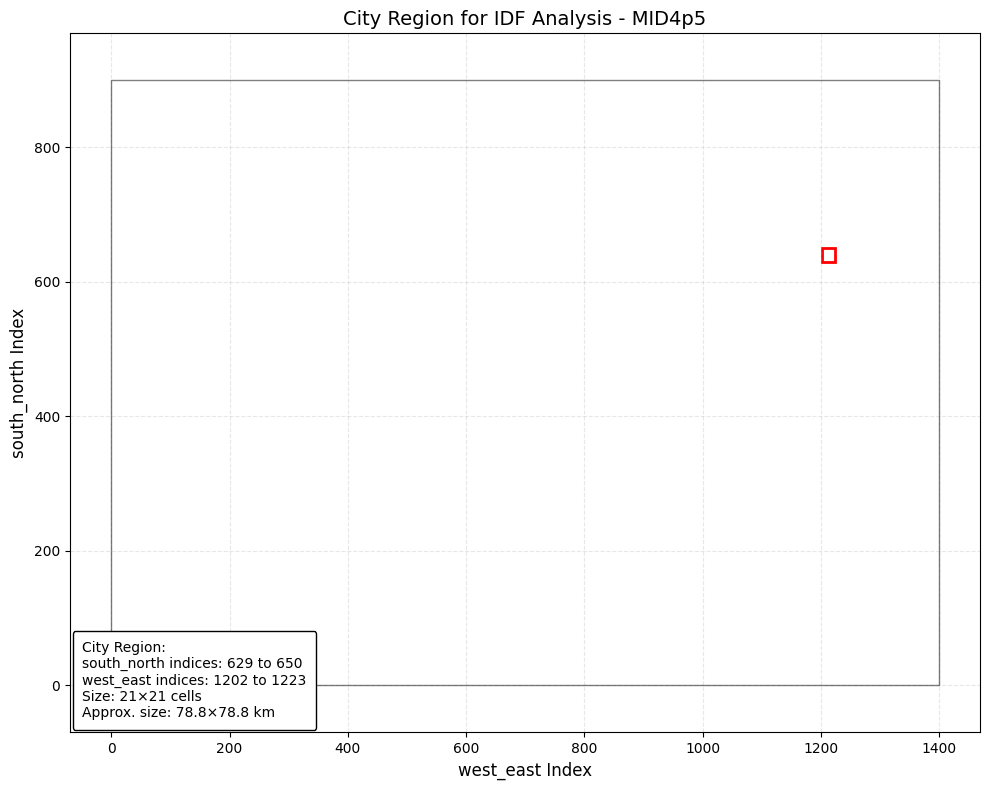

2026-07-25 18:16:09,856 - INFO - Testing city region for amarillo
2026-07-25 18:16:11,087 - INFO - Target coordinates: (35.2220, -101.8313)
2026-07-25 18:16:11,093 - INFO - Nearest grid cell: (35.2141, -101.8295) at indices (354, 594)
2026-07-25 18:16:11,129 - INFO - City region defined: south_north[344:365], west_east[584:605]
2026-07-25 18:16:11,135 - INFO - Region size: 21×21 cells
2026-07-25 18:16:11,142 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:17,219 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/amarillo_region_MID4p5.png


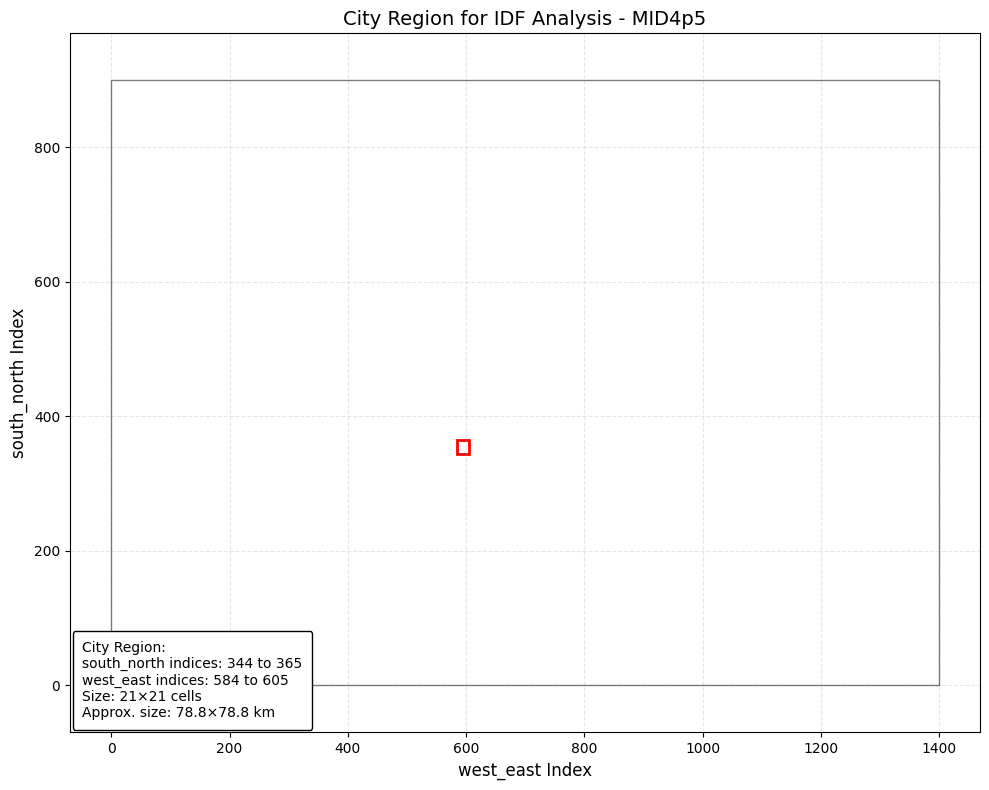

2026-07-25 18:16:19,047 - INFO - Testing city region for grand_junction
2026-07-25 18:16:20,464 - INFO - Target coordinates: (39.0639, -108.5506)
2026-07-25 18:16:20,472 - INFO - Nearest grid cell: (39.0640, -108.5602) at indices (481, 445)
2026-07-25 18:16:20,515 - INFO - City region defined: south_north[471:492], west_east[435:456]
2026-07-25 18:16:20,520 - INFO - Region size: 21×21 cells
2026-07-25 18:16:20,529 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:22,192 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/grand_junction_region_MID4p5.png


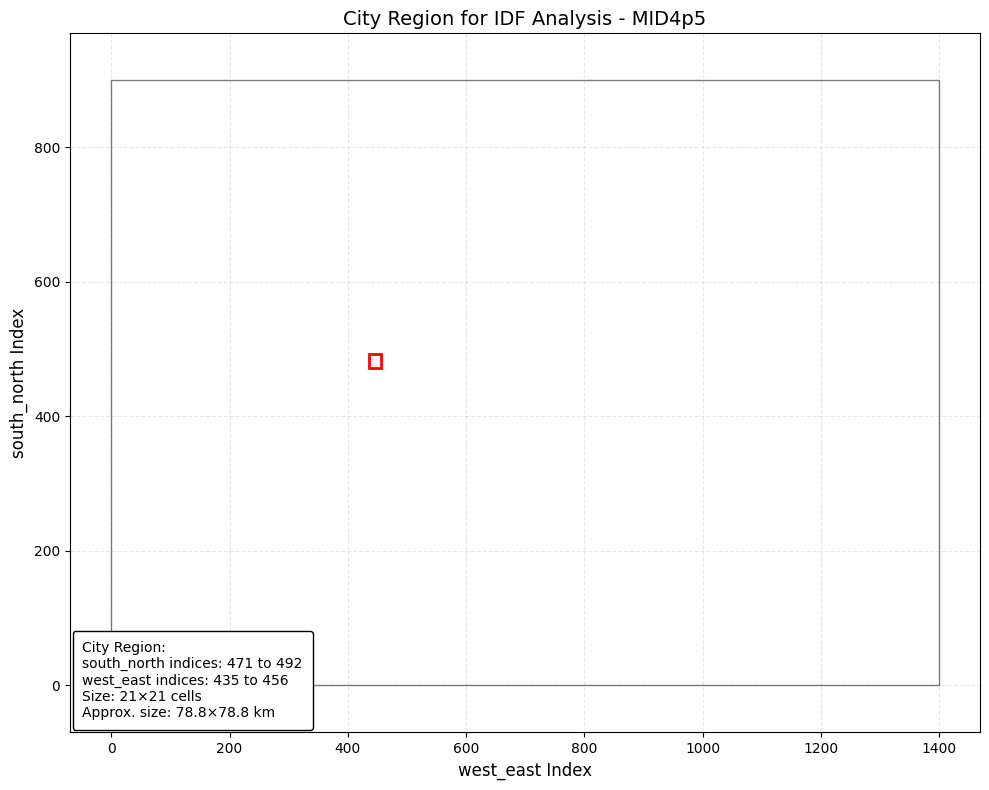

2026-07-25 18:16:23,449 - INFO - Testing city region for minneapolis
2026-07-25 18:16:23,816 - INFO - Target coordinates: (44.9778, -93.2650)
2026-07-25 18:16:23,822 - INFO - Nearest grid cell: (44.9942, -93.2817) at indices (644, 788)
2026-07-25 18:16:23,840 - INFO - City region defined: south_north[634:655], west_east[778:799]
2026-07-25 18:16:23,844 - INFO - Region size: 21×21 cells
2026-07-25 18:16:23,848 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:26,416 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/minneapolis_region_MID4p5.png


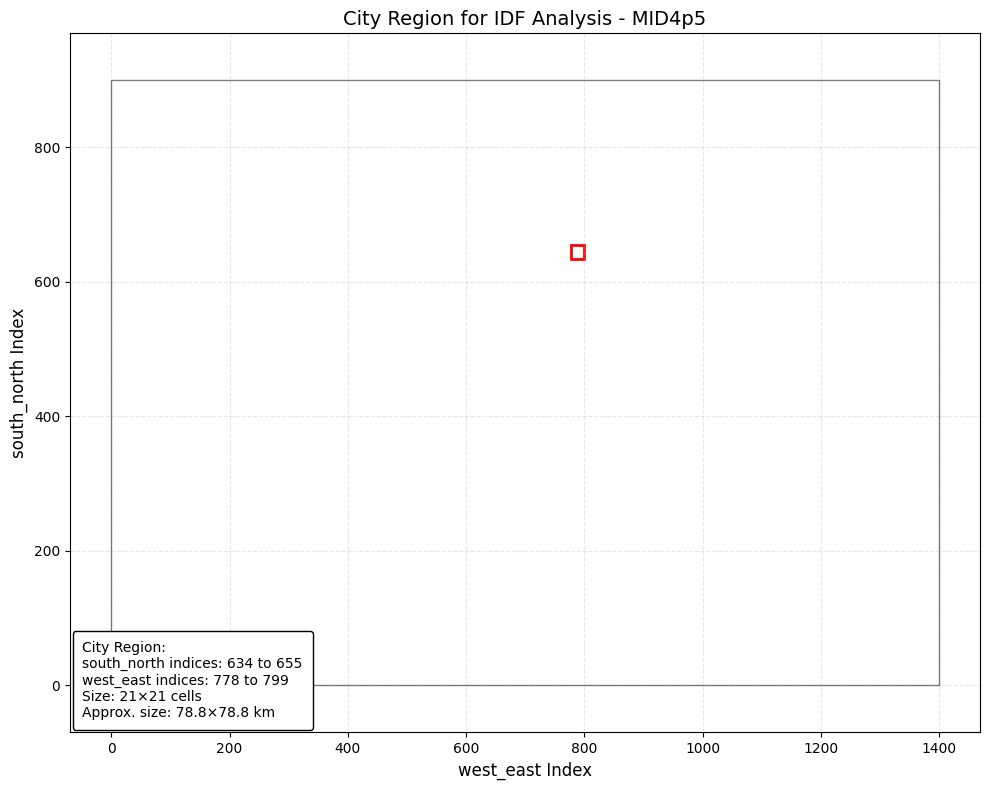

2026-07-25 18:16:26,986 - INFO - Testing city region for nashville
2026-07-25 18:16:27,582 - INFO - Target coordinates: (36.1627, -86.7816)
2026-07-25 18:16:27,594 - INFO - Nearest grid cell: (36.1761, -86.7874) at indices (395, 955)
2026-07-25 18:16:27,624 - INFO - City region defined: south_north[385:406], west_east[945:966]
2026-07-25 18:16:27,630 - INFO - Region size: 21×21 cells
2026-07-25 18:16:27,635 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:34,012 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/nashville_region_MID4p5.png


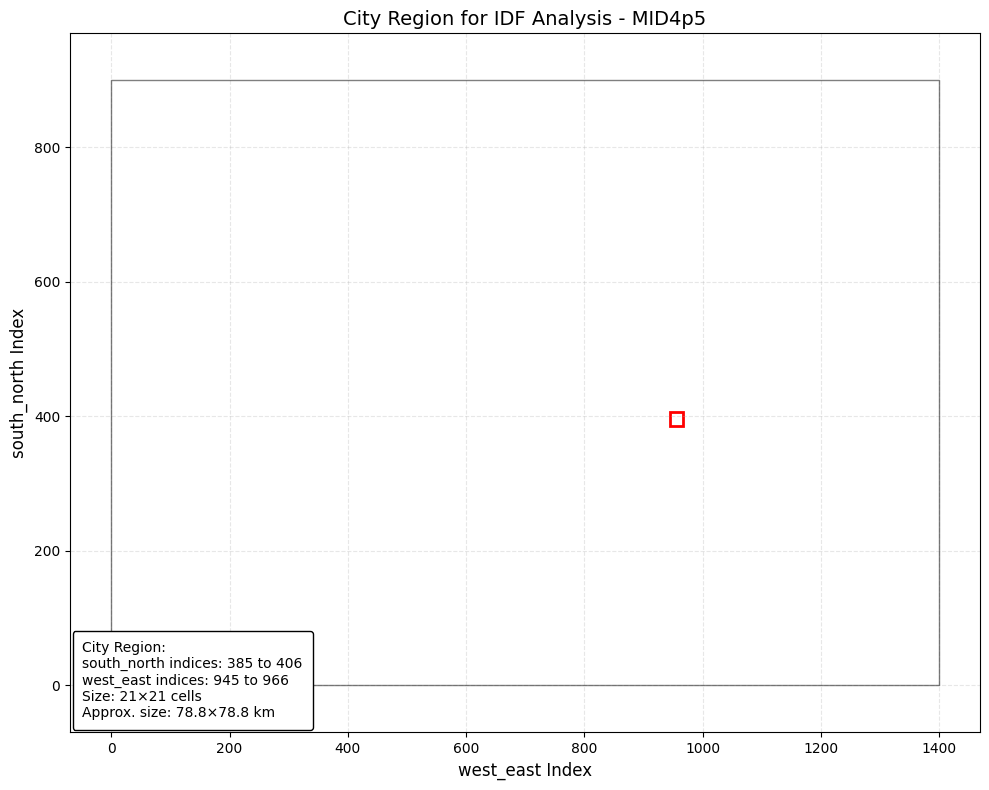

2026-07-25 18:16:36,082 - INFO - Testing city region for phoenix
2026-07-25 18:16:37,298 - INFO - Target coordinates: (33.4484, -112.0740)
2026-07-25 18:16:37,304 - INFO - Nearest grid cell: (33.4626, -112.0610) at indices (328, 339)
2026-07-25 18:16:37,335 - INFO - City region defined: south_north[318:339], west_east[329:350]
2026-07-25 18:16:37,341 - INFO - Region size: 21×21 cells
2026-07-25 18:16:37,347 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:40,502 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/phoenix_region_MID4p5.png


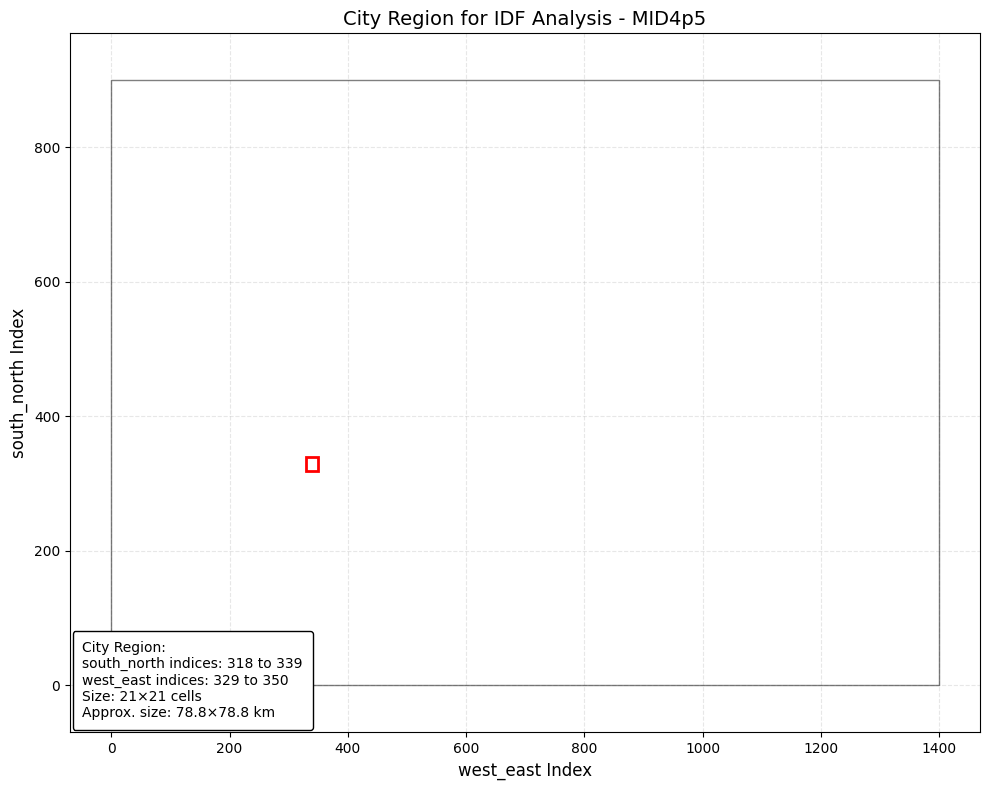

2026-07-25 18:16:40,890 - INFO - Testing city region for seattle
2026-07-25 18:16:41,252 - INFO - Target coordinates: (47.6062, -122.3321)
2026-07-25 18:16:41,257 - INFO - Nearest grid cell: (47.6183, -122.3410) at indices (788, 202)
2026-07-25 18:16:41,269 - INFO - City region defined: south_north[778:799], west_east[192:213]
2026-07-25 18:16:41,274 - INFO - Region size: 21×21 cells
2026-07-25 18:16:41,278 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:43,648 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/seattle_region_MID4p5.png


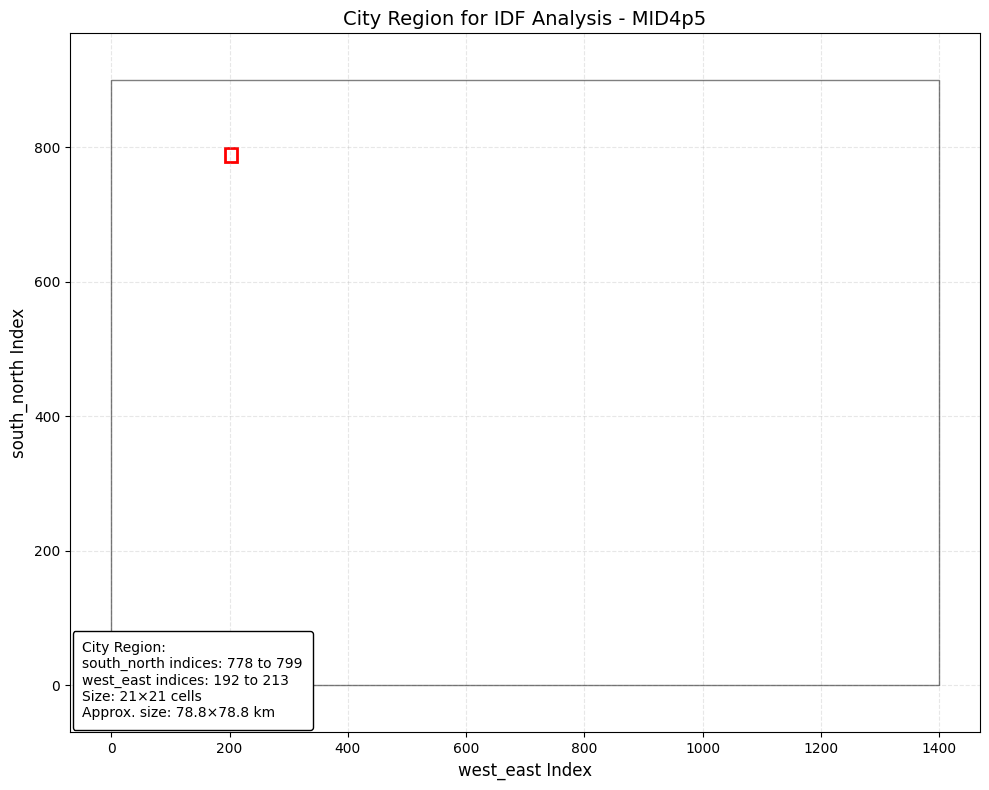

2026-07-25 18:16:44,087 - INFO - Testing city region for tallahassee
2026-07-25 18:16:44,314 - INFO - Target coordinates: (30.4518, -84.2807)
2026-07-25 18:16:44,319 - INFO - Nearest grid cell: (30.4489, -84.2783) at indices (234, 1039)
2026-07-25 18:16:44,329 - INFO - City region defined: south_north[224:245], west_east[1029:1050]
2026-07-25 18:16:44,334 - INFO - Region size: 21×21 cells
2026-07-25 18:16:44,343 - INFO - Approx physical size: 78.8×78.8 km
2026-07-25 18:16:45,448 - INFO - Saved city region plot to /home/scratch/idf_curves/MID4p5/tallahassee_region_MID4p5.png


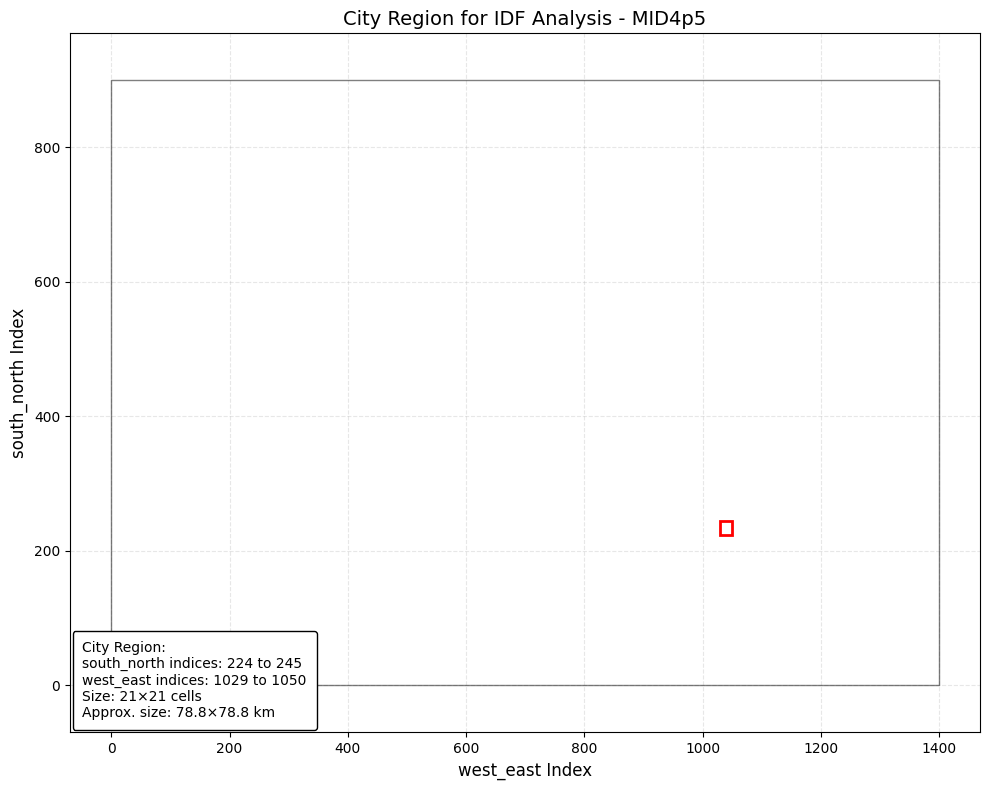

2026-07-25 18:16:45,816 - INFO - All helper function tests passed
Helper functions tests passed


In [5]:
# Test Helper Functions to make sure they are behaving

# Test file path generation for a water year
def test_get_files_in_date_range():
    """Test function to verify file path generation works correctly"""
    logger.info("Testing get_files_in_date_range function")
    
    # Test for a small date range (3 days)
    test_range = f"{HYDRO_YEAR_START}-10-01 to {HYDRO_YEAR_START}-10-03"
    files = get_files_in_date_range(DATA_PATH, test_range, -1, SCENARIO)
    
    # Log results
    logger.info(f"Found {len(files)} files for date range {test_range}")
    if len(files) > 0:
        logger.info(f"First file: {os.path.basename(files[0])}")
        logger.info(f"Last file: {os.path.basename(files[-1])}")
    else:
        logger.warning("No files found for test date range")
    
    return files

# Test city region definition
def test_city_region():
    """Test function to verify city region definition and visualization"""
    logger.info("Testing city region definition")
    
    # Get a sample file
    sample_file = find_sample_file(SCENARIO, HYDRO_YEAR_START)
    
    if sample_file is None:
        logger.error("Cannot test city region without a sample file")
        return None
    
    # Open sample file
    try:
        sample_ds = xr.open_dataset(sample_file)
        logger.info(f"Opened sample file: {sample_file}")
        
        # Test for each city region
        for city in CITY_REGIONS:
            city_name = city["name"]
            coords = city["coords"]
            size = city["size"]
            
            logger.info(f"Testing city region for {city_name}")
            
            # Convert coordinates to indices
            lat_idx, lon_idx = coords_to_indices(GRID_FILE, coords[0], coords[1])
            
            # Define city region
            region = get_city_region(sample_ds, 
                                    center_lat_idx=lat_idx, 
                                    center_lon_idx=lon_idx, 
                                    size=size)
            
            # Create plot
            fig = plot_city_region(sample_ds, region)
            
            # Save plot
            plot_path = f"{OUTPUT_DIR}/{city_name}_region_{SCENARIO}.png"
            fig.savefig(plot_path, dpi=300, bbox_inches='tight')
            logger.info(f"Saved city region plot to {plot_path}")
            
            # Show plot
            plt.show()
        
        # Close dataset
        sample_ds.close()
        
        return True
    except Exception as e:
        logger.error(f"Error testing city region: {str(e)}")
        return None

# Run tests
test_files = test_get_files_in_date_range()
test_regions = test_city_region()

# Summary of test results
if len(test_files) > 0 and test_regions:
    logger.info("All helper function tests passed")
    print("Helper functions tests passed")
else:
    logger.error("One or more helper function tests failed")
    print("Helper function tests failed")

In [6]:
# Core Function for Annual Maximum Calculation with Batch Processing

def calculate_annual_max_for_durations(scenario, year, durations, city_regions):
    """
    Calculate annual maximum precipitation intensities for various durations for multiple city regions,
    using memory-efficient batch processing with proper handling of rolling windows across batch boundaries.
    
    Parameters:
    -----------
    scenario : str
        Scenario name (e.g., "HIST", "MID4p5")
    year : int
        Starting year for the water year
    durations : list
        List of durations in number of 15-minute intervals
    city_regions : list
        List of dictionaries with city region information
    
    Returns:
    --------
    dict : Dictionary of city names to xarray.Dataset with annual maximum intensities
    """
    start_time = time.time()
    
    # Define date range for water year
    hours_offset = -1
    date_start = f'{year}-10-01'
    date_end = f'{year+1}-09-30'
    year_range = f'{year}-{year+1}'
    logger.info(f"Processing year range: {year_range}")
    
    # Get data path based on scenario
    data_path = DATA_PATH
    
    # Get files in date range
    files = get_files_in_date_range(data_path, f'{date_start} to {date_end}', hours_offset, scenario)
    files.sort()
    logger.info(f'Number of files: {len(files)}')
    
    if len(files) == 0:
        logger.error(f"No files found for {year_range}")
        return {}
    
    # Calculate max days required for the longest duration
    max_duration_in_days = max(durations) * 15 / (60 * 24)  # Convert from 15-min intervals to days
    rollover_days = int(np.ceil(max_duration_in_days))
    logger.info(f"Maximum duration: {max(durations)} time steps, requires {rollover_days} days of rollover data")
    
    # Initialize a dictionary to store dataset for each city
    city_datasets = {}
    
    # Initialize a dictionary to store maximum intensities for each city and duration
    max_intensities = {}
    for city_region in city_regions:
        city_name = city_region["name"]
        max_intensities[city_name] = {}
        
        for d in durations:
            # Convert duration to hours for naming
            hours = d * 15 / 60
            if hours < 1:
                duration_name = f"{int(hours * 60)}min"
            else:
                duration_name = f"{int(hours)}hr"
            max_intensities[city_name][duration_name] = None
    
    # Process files in batches to save memory
    batch_size = BATCH_SIZE
    
    # Initialize variables for batch processing
    prev_batch_data = {}  # Dictionary to store rollover data for each city
    rollover_steps = None  # Will be determined dynamically
    
    # Process each batch with overlapping files from the end of the previous batch
    for batch_start_idx in range(0, len(files), batch_size):
        batch_end_idx = min(batch_start_idx + batch_size, len(files))
        logger.info(f"Processing batch: files {batch_start_idx} to {batch_end_idx-1}")
        
        # Determine batch files
        batch_files = files[batch_start_idx:batch_end_idx]
        
        try:
            # Load batch files
            ds_batch = xr.open_mfdataset(batch_files, chunks='auto', combine='by_coords', engine='netcdf4')
            
            # Process each city region
            for city_region_info in city_regions:
                city_name = city_region_info["name"]
                indices = city_region_info["indices"]
                size = city_region_info["size"]
                
                logger.info(f"Processing {city_name} for batch {batch_start_idx//batch_size + 1}")
                
                # Define city region
                if batch_start_idx == 0:  # First batch, need to compute city_region
                    city_region = get_city_region(ds_batch, 
                                                center_lat_idx=indices[0], 
                                                center_lon_idx=indices[1], 
                                                size=size)
                else:
                    # Use the same region definition as before
                    city_region = get_city_region(ds_batch, 
                                                center_lat_idx=indices[0], 
                                                center_lon_idx=indices[1], 
                                                size=size)
                
                # Apply city region filter
                ds_city = ds_batch.isel(**city_region)
                
                # Check if we have rollover data from previous batch for this city
                if city_name in prev_batch_data and prev_batch_data[city_name] is not None:
                    logger.info(f"Including rollover data from previous batch for {city_name}")
                    # Concatenate with previous batch data along time dimension
                    ds_city_with_rollover = xr.concat([prev_batch_data[city_name], ds_city], dim="Time")
                else:
                    # First batch, just use current data
                    ds_city_with_rollover = ds_city
                
                # Dynamically determine steps per day if needed
                if rollover_steps is None and len(ds_city_with_rollover.Time) > 0:
                    # Get the first 2 days of data to determine steps per day
                    try:
                        # Try to extract timestamps using xarray functionality
                        timestamps = ds_city_with_rollover.Time.values
                        times = pd.to_datetime(timestamps)
                        
                        # Group by date and count
                        date_counts = times.map(lambda t: t.date()).value_counts()
                        
                        if len(date_counts) > 0:
                            # Use the mode (most common) number of steps per day
                            avg_steps_per_day = int(date_counts.mode()[0])
                            # Add a safety margin of 25% to handle irregular timesteps
                            rollover_steps = int(rollover_days * avg_steps_per_day * 1.25)
                            logger.info(f"Dynamically determined: ~{avg_steps_per_day} time steps per day")
                            logger.info(f"Using {rollover_steps} rollover steps with safety margin")
                        else:
                            # Fallback if no dates found
                            rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                            logger.warning(f"Unable to determine steps per day, using default with safety margin: {rollover_steps}")
                    except Exception as e:
                        # Fallback on error
                        rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                        logger.error(f"Error determining time steps per day: {str(e)}")
                        logger.info(f"Using default with safety margin: {rollover_steps}")
                
                # Save the last few days' data for the next batch's rollover
                if batch_end_idx < len(files):
                    try:
                        # Check if we have enough data for rollover
                        if len(ds_city_with_rollover.Time) > rollover_steps:
                            prev_batch_data[city_name] = ds_city_with_rollover.isel(Time=slice(-rollover_steps, None))
                        else:
                            # If the batch is smaller than the rollover window, use the entire batch
                            prev_batch_data[city_name] = ds_city_with_rollover
                            logger.warning(f"Batch size ({len(ds_city_with_rollover.Time)} steps) is smaller than required rollover ({rollover_steps} steps)")
                    except Exception as e:
                        logger.error(f"Error preparing rollover data: {str(e)}")
                        prev_batch_data[city_name] = None
                else:
                    # Last batch, no need for rollover
                    prev_batch_data[city_name] = None
                
                # Compute rolling precipitation sums for each duration
                for d in durations:
                    hours = d * 15 / 60
                    if hours < 1:
                        duration_name = f"{int(hours * 60)}min"
                    else:
                        duration_name = f"{int(hours)}hr"
                    
                    logger.info(f"Computing {duration_name} duration maxima for {city_name}...")
                    
                    try:
                        # Calculate rolling sum along time dimension
                        # Converting to mm/hr for intensity
                        rolling_sum = ds_city_with_rollover.AFWA_TOTPRECIP.rolling(Time=d, center=False).sum()
                        rolling_intensity = rolling_sum * (60 / (d * 15))  # Convert to mm/hr
                        
                        # For the first batch, use the full time series
                        # For subsequent batches, exclude the first (d-1) time steps where the rolling window
                        # doesn't have complete data
                        if batch_start_idx > 0 and d > 1:
                            # Exclude incomplete rolling windows at the start
                            valid_rolling_intensity = rolling_intensity.isel(Time=slice(d-1, None))
                        else:
                            valid_rolling_intensity = rolling_intensity
                        
                        # Get maximum value from this batch
                        with ProgressBar():
                            batch_max = valid_rolling_intensity.max(dim="Time", skipna=True).compute()
                        
                        # Update overall maximum if higher
                        if max_intensities[city_name][duration_name] is None:
                            max_intensities[city_name][duration_name] = batch_max
                        else:
                            max_intensities[city_name][duration_name] = xr.where(
                                batch_max > max_intensities[city_name][duration_name],
                                batch_max,
                                max_intensities[city_name][duration_name]
                            )
                    except Exception as e:
                        logger.error(f"Error computing {duration_name} maxima for {city_name}: {str(e)}")
                
                # Clean up to free memory
                ds_city.close()
                ds_city_with_rollover.close()
            
            # Clean up batch data to free memory
            ds_batch.close()
            gc.collect()
            
        except Exception as e:
            logger.error(f"Error processing batch {batch_start_idx//batch_size + 1}: {str(e)}")
    
    # Create a dataset for each city with all duration maxima
    for city_region_info in city_regions:
        city_name = city_region_info["name"]
        logger.info(f"Creating final dataset for {city_name}")
        
        ds_maxima = xr.Dataset()
        for duration_name, intensity in max_intensities[city_name].items():
            if intensity is not None:
                ds_maxima[f"max_intensity_{duration_name}"] = intensity
        
        # Add metadata
        ds_maxima.attrs['scenario'] = scenario
        ds_maxima.attrs['year_range'] = year_range
        ds_maxima.attrs['city_name'] = city_name
        ds_maxima.attrs['data_type'] = 'annual_maximum_precipitation_intensity'
        
        # Store in the dictionary
        city_datasets[city_name] = ds_maxima
    
    # Report processing time
    elapsed = time.time() - start_time
    logger.info(f"Processing time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    
    return city_datasets

In [7]:
# Process All Years and City Regions

def process_annual_maxima():
    """
    Process annual maximum precipitation for all years and city regions,
    with batch-major looping to minimize file I/O operations.
    
    Returns:
    --------
    dict : Dictionary with city names as keys and combined xarray.Dataset as values
    """
    # Dictionary to store combined annual maxima for each city
    combined_maxima = {}
    
    # Initialize data structures for each city and year
    for city_region in CITY_REGIONS:
        city_name = city_region["name"]
        logger.info(f"Initializing data structures for city region: {city_name}")
        
        # Create city-specific output directory
        city_output_dir = f"{OUTPUT_DIR}/{city_name}"
        os.makedirs(city_output_dir, exist_ok=True)
        
        # Initialize array in the combined_maxima dict
        combined_maxima[city_name] = []
    
    # Check available data for each year
    years_to_process = []
    for year in YEARS:
        # Look for sample file to confirm data exists
        sample_file = find_sample_file(SCENARIO, year)
        
        if sample_file is not None:
            years_to_process.append(year)
            logger.info(f"Found data for year {year} at {sample_file}")
        else:
            logger.warning(f"No data found for year {year}, skipping")
    
    if not years_to_process:
        logger.error(f"No data found for any year in range {HYDRO_YEAR_START}-{HYDRO_YEAR_END}")
        return {}
    
    logger.info(f"Will process {len(years_to_process)} years with available data: {years_to_process}")
    
    # Process each year
    for year in years_to_process:
        year_range = f"{year}-{year+1}"
        logger.info(f"Processing year range: {year_range}")
        
        # Check which cities we need to process for this year
        cities_to_process = []
        for city_region in CITY_REGIONS:
            city_name = city_region["name"]
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            year_file = f"{city_output_dir}/annual_maxima_{SCENARIO}_{year_range}_{city_name}_{VERSION_TAG}.nc"
            
            if not FORCE_RECALCULATION and os.path.exists(year_file):
                # Already processed, load from file
                logger.info(f"Loading pre-computed maxima for {city_name}, {year_range}")
                try:
                    ds_year = xr.open_dataset(year_file)
                    combined_maxima[city_name].append(ds_year)
                except Exception as e:
                    logger.error(f"Error loading pre-computed maxima: {str(e)}")
                    cities_to_process.append(city_region)
            else:
                # Need to process this city
                cities_to_process.append(city_region)
        
        if not cities_to_process:
            logger.info(f"All cities already processed for year {year_range}, skipping")
            continue
        
        logger.info(f"Processing year {year_range} for cities: {', '.join([c['name'] for c in cities_to_process])}")
        
        # Define date range for water year (We really shoud have put this in the config at the begining)
        hours_offset = -1
        date_start = f'{year}-10-01'
        date_end = f'{year+1}-09-30'
        
        # Get files in date range
        files = get_files_in_date_range(DATA_PATH, f'{date_start} to {date_end}', hours_offset, SCENARIO)
        files.sort()
        logger.info(f'Number of files for {year_range}: {len(files)}')
        
        if len(files) == 0:
            logger.error(f"No files found for {year_range}, skipping")
            continue
        
        # Calculate max days required for the longest duration
        max_duration_in_days = max(DURATIONS) * 15 / (60 * 24)
        rollover_days = int(np.ceil(max_duration_in_days))
        logger.info(f"Max duration: {max(DURATIONS)} time steps, requires {rollover_days} days of rollover data")
        
        # Initialize a dictionary to store maximum intensities for each city and duration
        max_intensities = {}
        for city_region in cities_to_process:
            city_name = city_region["name"]
            max_intensities[city_name] = {}
            
            for d in DURATIONS:
                hours = d * 15 / 60
                if hours < 1:
                    duration_name = f"{int(hours * 60)}min"
                else:
                    duration_name = f"{int(hours)}hr"
                max_intensities[city_name][duration_name] = None
        
        # Process files in batches to save memory
        batch_size = BATCH_SIZE
        
        # Initialize variables for batch processing
        prev_batch_data = {}  # Dictionary to store rollover data for each city
        rollover_steps = None  # Will be determined dynamically
        
        # Process each batch with overlapping files from the end of the previous batch
        for batch_start_idx in range(0, len(files), batch_size):
            batch_end_idx = min(batch_start_idx + batch_size, len(files))
            logger.info(f"Processing batch: files {batch_start_idx} to {batch_end_idx-1}")
            
            # Determine batch files
            batch_files = files[batch_start_idx:batch_end_idx]
            
            try:
                # Load batch files once for all cities
                logger.info(f"Loading batch files...")
                ds_batch = xr.open_mfdataset(batch_files, chunks='auto', combine='by_coords', engine='netcdf4')
                
                # Process each city region
                for city_region in cities_to_process:
                    city_name = city_region["name"]
                    coords = city_region["coords"]
                    size = city_region["size"]
                    
                    logger.info(f"Processing {city_name} for batch {batch_start_idx//batch_size + 1}")
                    
                    # Convert coordinates to indices if needed
                    if batch_start_idx == 0:  # First batch, compute indices
                        lat_idx, lon_idx = coords_to_indices(GRID_FILE, coords[0], coords[1])
                        # Store indices for subsequent batches
                        city_region["_indices"] = [lat_idx, lon_idx]
                    else:
                        # Use cached indices
                        lat_idx, lon_idx = city_region["_indices"]
                    
                    # Define city region
                    city_region_dict = get_city_region(ds_batch, 
                                               center_lat_idx=lat_idx, 
                                               center_lon_idx=lon_idx, 
                                               size=size)
                    
                    # Apply city region filter
                    logger.info(f"Extracting city region data for {city_name}")
                    ds_city = ds_batch.isel(**city_region_dict)
                    
                    # Check if we have rollover data from previous batch for this city
                    if city_name in prev_batch_data and prev_batch_data[city_name] is not None:
                        logger.info(f"Including rollover data from previous batch for {city_name}")
                        # Concatenate with previous batch data along time dimension
                        ds_city_with_rollover = xr.concat([prev_batch_data[city_name], ds_city], dim="Time")
                    else:
                        # First batch, just use current data
                        ds_city_with_rollover = ds_city
                    
                    # Dynamically determine steps per day if needed
                    if rollover_steps is None and len(ds_city_with_rollover.Time) > 0:
                        # Get the first 2 days of data to determine steps per day
                        try:
                            # Try to extract timestamps using xarray functionality
                            timestamps = ds_city_with_rollover.Time.values
                            times = pd.to_datetime(timestamps)
                            
                            # Group by date and count
                            date_counts = times.map(lambda t: t.date()).value_counts()
                            
                            if len(date_counts) > 0:
                                # Use the mode (most common) number of steps per day
                                avg_steps_per_day = int(date_counts.mode()[0])
                                # Add a safety margin of 25% to handle irregular timesteps
                                rollover_steps = int(rollover_days * avg_steps_per_day * 1.25)
                                logger.info(f"Dynamically determined: ~{avg_steps_per_day} time steps per day")
                                logger.info(f"Using {rollover_steps} rollover steps with safety margin")
                            else:
                                # Fallback if no dates found
                                rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                                logger.warning(f"Unable to determine steps per day, using default: {rollover_steps}")
                        except Exception as e:
                            # Fallback on error
                            rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                            logger.error(f"Error determining time steps per day: {str(e)}")
                            logger.info(f"Using default with safety margin: {rollover_steps}")
                    
                    # Save the last few days' data for the next batch's rollover
                    if batch_end_idx < len(files):
                        try:
                            # Check if we have enough data for rollover
                            if len(ds_city_with_rollover.Time) > rollover_steps:
                                prev_batch_data[city_name] = ds_city_with_rollover.isel(Time=slice(-rollover_steps, None))
                            else:
                                # If the batch is smaller than the rollover window, use the entire batch
                                prev_batch_data[city_name] = ds_city_with_rollover
                                logger.warning(f"Batch size ({len(ds_city_with_rollover.Time)} steps) is smaller than required rollover ({rollover_steps} steps)")
                        except Exception as e:
                            logger.error(f"Error preparing rollover data for {city_name}: {str(e)}")
                            prev_batch_data[city_name] = None
                    else:
                        # Last batch, no need for rollover
                        prev_batch_data[city_name] = None
                    
                    # Compute rolling precipitation sums for each duration
                    for d in DURATIONS:
                        hours = d * 15 / 60
                        if hours < 1:
                            duration_name = f"{int(hours * 60)}min"
                        else:
                            duration_name = f"{int(hours)}hr"
                        
                        logger.info(f"Computing {duration_name} duration maxima for {city_name}...")
                        
                        try:
                            # Check if we have enough time steps
                            if len(ds_city_with_rollover.Time) < d:
                                logger.warning(f"Not enough time steps ({len(ds_city_with_rollover.Time)}) for duration {d}")
                                continue
                            
                            # Calculate rolling sum along time dimension
                            # Converting to mm/hr for intensity
                            rolling_sum = ds_city_with_rollover.AFWA_TOTPRECIP.rolling(Time=d, center=False).sum()
                            rolling_intensity = rolling_sum * (60 / (d * 15))  # Convert to mm/hr
                            
                            # For the first batch, use the full time series
                            # For subsequent batches, exclude the first (d-1) time steps where the rolling window
                            # doesn't have complete data
                            if batch_start_idx > 0 and d > 1:
                                # Exclude incomplete rolling windows at the start
                                valid_rolling_intensity = rolling_intensity.isel(Time=slice(d-1, None))
                            else:
                                valid_rolling_intensity = rolling_intensity
                            
                            # Check if we have valid data
                            if len(valid_rolling_intensity.Time) == 0:
                                logger.warning(f"No valid time steps for {duration_name} after filtering")
                                continue
                            
                            # Get maximum value from this batch
                            with ProgressBar():
                                batch_max = valid_rolling_intensity.max(dim="Time", skipna=True).compute()
                            
                            # Log the max value found
                            max_value = float(batch_max.max().values)
                            if not np.isnan(max_value):
                                logger.info(f"Maximum {duration_name} intensity in batch: {max_value:.2f} mm/hr")
                            
                            # Update overall maximum if higher
                            if max_intensities[city_name][duration_name] is None:
                                max_intensities[city_name][duration_name] = batch_max
                            else:
                                max_intensities[city_name][duration_name] = xr.where(
                                    batch_max > max_intensities[city_name][duration_name],
                                    batch_max,
                                    max_intensities[city_name][duration_name]
                                )
                        except Exception as e:
                            logger.error(f"Error computing {duration_name} maxima for {city_name}: {str(e)}")
                    
                    # Clean up to free memory
                    ds_city.close()
                    ds_city_with_rollover.close()
                
                # Clean up batch data to free memory
                ds_batch.close()
                gc.collect()
                
            except Exception as e:
                logger.error(f"Error processing batch {batch_start_idx//batch_size + 1}: {str(e)}")
        
        # Create a dataset for each city with all duration maxima and save
        for city_region in cities_to_process:
            city_name = city_region["name"]
            logger.info(f"Creating final dataset for {city_name}, year {year_range}")
            
            ds_maxima = xr.Dataset()
            durations_found = 0
            
            for duration_name, intensity in max_intensities[city_name].items():
                if intensity is not None:
                    ds_maxima[f"max_intensity_{duration_name}"] = intensity
                    durations_found += 1
            
            if durations_found == 0:
                logger.error(f"No valid durations found for {city_name}, year {year_range}")
                continue
            
            # Add metadata
            ds_maxima.attrs['scenario'] = SCENARIO
            ds_maxima.attrs['year_range'] = year_range
            ds_maxima.attrs['city_name'] = city_name
            ds_maxima.attrs['data_type'] = 'annual_maximum_precipitation_intensity'
            ds_maxima.attrs['creation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            ds_maxima.attrs['durations_found'] = durations_found
            ds_maxima.attrs['durations_processed'] = len(DURATIONS)
            
            # Save individual year file
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            year_file = f"{city_output_dir}/annual_maxima_{SCENARIO}_{year_range}_{city_name}_{VERSION_TAG}.nc"
            logger.info(f"Saving annual maxima to {year_file}")
            ds_maxima.to_netcdf(path=year_file)
            
            # Add to combined list
            combined_maxima[city_name].append(ds_maxima)
    
    # Combine annual maxima into a single dataset for each city
    final_combined_maxima = {}
    
    for city_name, yearly_datasets in combined_maxima.items():
        if not yearly_datasets:
            logger.error(f"No data found for any year for {city_name}")
            continue
        
        # Get years that have data
        years_with_data = []
        for ds in yearly_datasets:
            year_range = ds.attrs.get('year_range', '')
            if year_range:
                year = int(year_range.split('-')[0])
                years_with_data.append(year)
        
        logger.info(f"Combining annual maxima for {city_name} with {len(years_with_data)} years: {years_with_data}")
        
        try:
            # Combine all years
            combined_ds = xr.concat(yearly_datasets, dim="year")
            combined_ds = combined_ds.assign_coords(year=years_with_data)
            
            # Add city name metadata
            combined_ds.attrs['city_name'] = city_name
            combined_ds.attrs['scenario'] = SCENARIO
            combined_ds.attrs['year_range_full'] = f"{min(years_with_data)}-{max(years_with_data)}"
            combined_ds.attrs['data_type'] = 'combined_annual_maximum_precipitation_intensity'
            combined_ds.attrs['creation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            combined_ds.attrs['years_with_data'] = len(years_with_data)
            combined_ds.attrs['years_missing'] = len(YEARS) - len(years_with_data)
            
            # Save the combined maxima
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            combined_file = f"{city_output_dir}/combined_annual_maxima_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
            logger.info(f"Saving combined annual maxima to {combined_file}")
            combined_ds.to_netcdf(path=combined_file)
            
            # Store in dictionary
            final_combined_maxima[city_name] = combined_ds
        except Exception as e:
            logger.error(f"Error combining annual maxima for {city_name}: {str(e)}")
    
    # Return the dictionary of city datasets
    return final_combined_maxima

# Run the processing function with better error handling
logger.info("Starting annual maxima processing with batch-major approach")
try:
    start_time = time.time()
    city_maxima = process_annual_maxima()
    elapsed = time.time() - start_time
    logger.info(f"Completed annual maxima processing in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    
    # Show summary of results
    if city_maxima:
        print("\n=== ANNUAL MAXIMA PROCESSING SUMMARY ===")
        for city_name, ds in city_maxima.items():
            print(f"✅ {city_name}: {len(ds.year)} years of data processed")
            
            # Get a list of durations processed
            durations = []
            for var in ds.data_vars:
                if var.startswith("max_intensity_"):
                    durations.append(var.replace("max_intensity_", ""))
            
            print(f"   Durations: {', '.join(durations)}")
            print(f"   Output directory: {OUTPUT_DIR}/{city_name}")
            print("")
    else:
        print("No cities were successfully processed")
        logger.error("No cities were successfully processed")
except Exception as e:
    logger.error(f"Error in annual maxima processing: {str(e)}")
    import traceback
    logger.error(traceback.format_exc())
    print(f"Error in processing: {str(e)}")
    # Initialize empty dictionary if processing failed
    city_maxima = {}

2026-07-25 18:16:46,035 - INFO - Starting annual maxima processing with batch-major approach
2026-07-25 18:16:46,040 - INFO - Initializing data structures for city region: albany
2026-07-25 18:16:46,049 - INFO - Initializing data structures for city region: amarillo
2026-07-25 18:16:46,052 - INFO - Initializing data structures for city region: grand_junction
2026-07-25 18:16:46,063 - INFO - Initializing data structures for city region: minneapolis
2026-07-25 18:16:46,066 - INFO - Initializing data structures for city region: nashville
2026-07-25 18:16:46,074 - INFO - Initializing data structures for city region: phoenix
2026-07-25 18:16:46,077 - INFO - Initializing data structures for city region: seattle
2026-07-25 18:16:46,079 - INFO - Initializing data structures for city region: tallahassee
2026-07-25 18:16:46,081 - INFO - Looking for sample file for MID4p5, year 2040
2026-07-25 18:16:46,085 - INFO - Found sample file at /home/scratch/WRF_BCC/precipitation/AFWA_TOTPRECIP/mid_centur

In [8]:
# Validate Processed Data

def validate_annual_maxima(city_maxima):
    """
    Perform validation checks on the processed annual maxima data.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    
    Returns:
    --------
    dict : Dictionary with validation results for each city
    """
    validation_results = {}
    
    for city_name, ds in city_maxima.items():
        logger.info(f"Validating data for {city_name}")
        city_result = {"pass": True, "warnings": [], "errors": []}
        
        # Check 1: Ensure we have all expected years
        expected_years = set(YEARS)
        actual_years = set(ds.year.values)
        missing_years = expected_years - actual_years
        
        if missing_years:
            msg = f"Missing {len(missing_years)} years: {sorted(missing_years)}"
            city_result["warnings"].append(msg)
            logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 2: Check for NaN values in the intensity data
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                nan_percentage = float(np.isnan(ds[var].values).sum()) / ds[var].size * 100
                
                if nan_percentage > 0:
                    msg = f"{var}: {nan_percentage:.2f}% NaN values"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                    
                    if nan_percentage > 50:
                        msg = f"{var}: More than 50% NaN values - data may be unreliable"
                        city_result["errors"].append(msg)
                        city_result["pass"] = False
                        logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 3: Basic sanity check on maximum values
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                # Skip if all NaN
                if np.isnan(ds[var].values).all():
                    msg = f"{var}: All values are NaN"
                    city_result["errors"].append(msg)
                    city_result["pass"] = False
                    logger.error(f"Validation for {city_name}: {msg}")
                    continue
                
                max_value = float(np.nanmax(ds[var].values))
                min_value = float(np.nanmin(ds[var].values))
                
                # Check for negative values (should never happen for precipitation)
                if min_value < 0:
                    msg = f"{var}: Negative values found (min: {min_value:.2f})"
                    city_result["errors"].append(msg)
                    city_result["pass"] = False
                    logger.error(f"Validation for {city_name}: {msg}")
                
                # Check for suspiciously high values
                # These thresholds are example values and should be adjusted based on local climate
                # 15min intensity - anything over 300 mm/hr is extreme
                if var == "max_intensity_15min" and max_value > 300:
                    msg = f"{var}: Extremely high 15min intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                # 1hr intensity - anything over 200 mm/hr is extreme
                elif var == "max_intensity_1hr" and max_value > 200:
                    msg = f"{var}: Extremely high 1hr intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                # 24hr intensity - anything over 50 mm/hr is extreme
                elif var == "max_intensity_24hr" and max_value > 50:
                    msg = f"{var}: Extremely high 24hr intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 4: Duration relationship check
        # Intensity should generally decrease with increasing duration
        duration_order = []
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                duration_str = var.replace("max_intensity_", "")
                if duration_str.endswith("min"):
                    minutes = int(duration_str.replace("min", ""))
                    duration_order.append((minutes / 60, var))  # Convert to hours
                elif duration_str.endswith("hr"):
                    hours = int(duration_str.replace("hr", ""))
                    duration_order.append((hours, var))
        
        # Sort by duration
        duration_order.sort()
        
        # Check that intensity decreases with increasing duration
        for i in range(len(duration_order) - 1):
            _, var1 = duration_order[i]
            _, var2 = duration_order[i + 1]
            
            # Calculate means to compare (excluding NaNs)
            mean1 = float(np.nanmean(ds[var1].values))
            mean2 = float(np.nanmean(ds[var2].values))
            
            if mean1 <= mean2:
                msg = f"Duration relationship error: {var1} mean ({mean1:.2f}) <= {var2} mean ({mean2:.2f})"
                city_result["errors"].append(msg)
                city_result["pass"] = False
                logger.error(f"Validation for {city_name}: {msg}")
        
        # Store results
        validation_results[city_name] = city_result
    
    return validation_results

# Run validation if we have data
if city_maxima:
    logger.info("Validating processed data")
    validation_results = validate_annual_maxima(city_maxima)
    
    # Print validation summary
    print("\n=== VALIDATION SUMMARY ===")
    for city_name, result in validation_results.items():
        if result["pass"]:
            print(f"{city_name}: PASSED validation")
        else:
            print(f"{city_name}: FAILED validation")
        
        if result["warnings"]:
            print(f"   Warnings ({len(result['warnings'])}):")
            for warning in result["warnings"][:3]:  # Show only first 3 warnings
                print(f"   - {warning}")
            if len(result["warnings"]) > 3:
                print(f"   - ... and {len(result['warnings']) - 3} more warnings (see log)")
        
        if result["errors"]:
            print(f"   Errors ({len(result['errors'])}):")
            for error in result["errors"]:
                print(f"   - {error}")
        
        print("")
else:
    print("No data to validate")

2026-07-25 18:16:57,413 - INFO - Validating processed data
2026-07-25 18:16:57,420 - INFO - Validating data for albany
2026-07-25 18:16:57,484 - INFO - Validating data for amarillo
2026-07-25 18:16:57,532 - INFO - Validating data for grand_junction
2026-07-25 18:16:57,579 - INFO - Validating data for minneapolis
2026-07-25 18:16:57,622 - INFO - Validating data for nashville
2026-07-25 18:16:57,663 - INFO - Validating data for phoenix
2026-07-25 18:16:57,750 - INFO - Validating data for seattle
2026-07-25 18:16:57,796 - INFO - Validating data for tallahassee

=== VALIDATION SUMMARY ===
albany: PASSED validation

amarillo: PASSED validation

grand_junction: PASSED validation

minneapolis: PASSED validation

nashville: PASSED validation

phoenix: PASSED validation

seattle: PASSED validation

tallahassee: PASSED validation



In [9]:
# Gumbel Distribution Fitting Functions

def fit_gumbel_distribution(annual_maxima):
    """
    Fit Gumbel distribution to annual maximum precipitation data.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with distribution parameters and diagnostic metrics
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 5:
        # Not enough data for reliable fit
        return {
            'mu': np.nan,
            'beta': np.nan,
            'mean': np.nan,
            'std': np.nan,
            'valid_points': len(valid_data),
            'status': 'insufficient_data'
        }
    
    # Calculate sample statistics
    mean = np.mean(valid_data)
    std = np.std(valid_data)
    
    # Calculate Gumbel parameters
    # beta = scale parameter, mu = location parameter
    beta = (np.sqrt(6) / np.pi) * std
    mu = mean - 0.5772 * beta
    
    return {
        'mu': mu,
        'beta': beta,
        'mean': mean,
        'std': std,
        'valid_points': len(valid_data),
        'status': 'success'
    }

def calculate_gumbel_quantiles(params, return_periods):
    """
    Calculate precipitation intensities for specified return periods using Gumbel distribution.
    
    Parameters:
    -----------
    params : dict
        Dictionary with Gumbel distribution parameters (mu, beta)
    return_periods : array-like
        Array of return periods in years
    
    Returns:
    --------
    numpy.ndarray : Array of precipitation intensities for each return period
    """
    if np.isnan(params['mu']) or np.isnan(params['beta']):
        return np.full(len(return_periods), np.nan)
    
    mu = params['mu']
    beta = params['beta']
    
    # Calculate quantiles for each return period
    quantiles = []
    
    for rp in return_periods:
        # Non-exceedance probability (annual)
        p = 1 - 1/rp
        
        # Reduced variate
        y = -np.log(-np.log(p))
        
        # Gumbel quantile function
        quantile = mu + beta * y
        quantiles.append(quantile)
    
    return np.array(quantiles)

def bootstrap_gumbel_confidence_intervals(annual_maxima, return_periods, n_bootstrap=1000, confidence_level=0.95):
    """
    Calculate confidence intervals for Gumbel quantiles using bootstrap resampling.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    return_periods : array-like
        Array of return periods in years
    n_bootstrap : int
        Number of bootstrap samples
    confidence_level : float
        Confidence level (0.0-1.0)
    
    Returns:
    --------
    dict : Dictionary with lower and upper confidence bounds
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 5:
        # Not enough data for reliable bootstrap
        return {
            'lower': np.full(len(return_periods), np.nan),
            'upper': np.full(len(return_periods), np.nan),
            'status': 'insufficient_data'
        }
    
    # Initialize arrays to store bootstrap results
    bootstrap_quantiles = np.zeros((n_bootstrap, len(return_periods)))
    
    # Generate bootstrap samples
    for i in range(n_bootstrap):
        # Generate bootstrap sample (resample with replacement)
        bootstrap_sample = np.random.choice(valid_data, size=len(valid_data), replace=True)
        
        # Fit Gumbel distribution
        params = fit_gumbel_distribution(bootstrap_sample)
        
        # Calculate quantiles
        bootstrap_quantiles[i, :] = calculate_gumbel_quantiles(params, return_periods)
    
    # Calculate confidence intervals
    alpha = 1 - confidence_level
    lower_percentile = alpha / 2 * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.nanpercentile(bootstrap_quantiles, lower_percentile, axis=0)
    upper_bound = np.nanpercentile(bootstrap_quantiles, upper_percentile, axis=0)
    
    return {
        'lower': lower_bound,
        'upper': upper_bound,
        'samples': bootstrap_quantiles,
        'status': 'success'
    }

def gumbel_plotting_positions(annual_maxima):
    """
    Calculate empirical plotting positions for Gumbel probability plot.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with plotting data (ordered intensities and reduced variates)
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 2:
        return {
            'intensity': np.array([]),
            'reduced_variate': np.array([]),
            'status': 'insufficient_data'
        }
    
    # Sort the data (ascending)
    sorted_data = np.sort(valid_data)
    
    # Calculate plotting positions using Weibull formula
    n = len(sorted_data)
    rank = np.arange(1, n + 1)
    prob = rank / (n + 1)  # Weibull plotting position (i/(n+1))
    
    # Calculate reduced variates
    reduced_variates = -np.log(-np.log(prob))
    
    return {
        'intensity': sorted_data,
        'reduced_variate': reduced_variates,
        'status': 'success'
    }

def gumbel_goodness_of_fit(annual_maxima):
    """
    Calculate goodness of fit statistics for Gumbel distribution.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with goodness of fit statistics
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 5:
        return {
            'r_squared': np.nan,
            'status': 'insufficient_data'
        }
    
    # Get plotting positions
    plot_data = gumbel_plotting_positions(annual_maxima)
    if plot_data['status'] != 'success':
        return {
            'r_squared': np.nan,
            'status': 'plotting_error'
        }
    
    intensity = plot_data['intensity']
    reduced_variate = plot_data['reduced_variate']
    
    # Fit Gumbel distribution
    params = fit_gumbel_distribution(annual_maxima)
    if params['status'] != 'success':
        return {
            'r_squared': np.nan,
            'status': 'fitting_error'
        }
    
    # Calculate theoretical intensities using reduced variates
    theoretical = params['mu'] + params['beta'] * reduced_variate
    
    # Calculate R²
    ss_tot = np.sum((intensity - np.mean(intensity))**2)
    ss_res = np.sum((intensity - theoretical)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    return {
        'r_squared': r_squared,
        'observed': intensity,
        'theoretical': theoretical,
        'reduced_variate': reduced_variate,
        'status': 'success'
    }

# Test the functions on a simple example
def test_gumbel_functions():
    """Test Gumbel fitting and calculation functions on a simple dataset"""
    # Generate a sample dataset (log-normal distribution for semi-realistic skew, this is just for ballpark testing)
    np.random.seed(42)
    sample_data = np.exp(np.random.normal(2, 0.5, size=15))
    
    # Add some NaNs to test handling
    sample_data[0] = np.nan
    
    # Fit Gumbel distribution
    gumbel_params = fit_gumbel_distribution(sample_data)
    print("Gumbel Distribution Parameters:")
    print(f"  μ (location): {gumbel_params['mu']:.4f}")
    print(f"  β (scale): {gumbel_params['beta']:.4f}")
    print(f"  Mean: {gumbel_params['mean']:.4f}")
    print(f"  Std Dev: {gumbel_params['std']:.4f}")
    print(f"  Valid data points: {gumbel_params['valid_points']}")
    
    # Calculate quantiles for various return periods
    return_periods = [2, 5, 10, 25, 50, 100]
    quantiles = calculate_gumbel_quantiles(gumbel_params, return_periods)
    
    print("\nQuantiles for Return Periods:")
    for rp, q in zip(return_periods, quantiles):
        print(f"  {rp}-year: {q:.4f}")
    
    # Calculate confidence intervals
    ci = bootstrap_gumbel_confidence_intervals(sample_data, return_periods, n_bootstrap=100)
    
    print("\nConfidence Intervals (95%):")
    for i, rp in enumerate(return_periods):
        lower = ci['lower'][i]
        upper = ci['upper'][i]
        print(f"  {rp}-year: {lower:.4f} - {quantiles[i]:.4f} - {upper:.4f}")
    
    # Calculate goodness of fit
    gof = gumbel_goodness_of_fit(sample_data)
    print(f"\nGoodness of fit: R² = {gof['r_squared']:.4f}")
    
    # Create a simple Gumbel probability plot
    plot_data = gumbel_plotting_positions(sample_data)
    
    plt.figure(figsize=(8, 6))
    plt.plot(plot_data['reduced_variate'], plot_data['intensity'], 'bo', label='Observed')
    
    # Plot the fitted line
    x_line = np.linspace(min(plot_data['reduced_variate'])-0.5, 
                         max(plot_data['reduced_variate'])+0.5, 100)
    y_line = gumbel_params['mu'] + gumbel_params['beta'] * x_line
    plt.plot(x_line, y_line, 'r-', label=f'Fitted (R² = {gof["r_squared"]:.4f})')
    
    plt.xlabel('Reduced Variate (-ln(-ln(p)))')
    plt.ylabel('Intensity')
    plt.title('Gumbel Probability Plot')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    return "Tests completed"

# Uncomment to run the test
# test_gumbel_functions()

In [10]:
# IDF Curve Calculation Function 

def calculate_idf_curves(city_maxima, city_name, return_periods=None, n_bootstrap=1000):
    """
    Calculate Intensity-Duration-Frequency (IDF) curves for a city region.
    Enhanced to handle sparse or missing data more robustly.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    city_name : str
        Name of the city to calculate IDF curves for
    return_periods : list, optional
        List of return periods in years, defaults to RETURN_PERIODS if None
    n_bootstrap : int
        Number of bootstrap samples for confidence intervals
    
    Returns:
    --------
    xarray.Dataset : Dataset with IDF curve data
    """
    # Check inputs
    if city_name not in city_maxima:
        logger.error(f"No data found for {city_name}")
        return None
    
    # Get the dataset for this city
    ds = city_maxima[city_name]
    
    # Log detailed information about the dataset
    logger.info(f"Processing IDF curves for {city_name}")
    logger.info(f"Number of years with data: {len(ds.year)}")
    
    # Use default return periods if not specified
    if return_periods is None:
        return_periods = RETURN_PERIODS
    
    # Check if we have enough years for the requested return periods
    max_rp = max(return_periods)
    if max_rp > len(ds.year) * 2:
        logger.warning(f"Maximum return period ({max_rp} years) is more than twice the record length ({len(ds.year)} years)")
        logger.warning(f"Results for return periods > {len(ds.year)*2} years will have high uncertainty")
    
    # Get dimension information
    if 'south_north' in ds.dims:
        lat_dim = 'south_north'
    elif 'lat' in ds.dims:
        lat_dim = 'lat'
    else:
        lat_dim = [d for d in ds.dims if d != 'year'][0]
        
    if 'west_east' in ds.dims:
        lon_dim = 'west_east'
    elif 'lon' in ds.dims:
        lon_dim = 'lon'
    else:
        lon_dim = [d for d in ds.dims if d != 'year' and d != lat_dim][0]
    
    # Get grid dimensions
    lat_size = ds.dims[lat_dim]
    lon_size = ds.dims[lon_dim]
    
    # Get duration information
    durations = []
    duration_names = []
    
    for var in ds.data_vars:
        if var.startswith("max_intensity_"):
            duration_names.append(var.replace("max_intensity_", ""))
    
    if not duration_names:
        logger.error(f"No duration variables found for {city_name}")
        return None
    
    # Convert duration names to hours (for sorting)
    for name in duration_names:
        if name.endswith("min"):
            hours = float(name.replace("min", "")) / 60
        elif name.endswith("hr"):
            hours = float(name.replace("hr", ""))
        else:
            hours = np.nan
        durations.append(hours)
    
    # Sort durations
    sorted_idx = np.argsort(durations)
    durations = [durations[i] for i in sorted_idx]
    duration_names = [duration_names[i] for i in sorted_idx]
    
    logger.info(f"Calculating IDF curves for {city_name} with {len(durations)} durations")
    logger.info(f"Durations: {', '.join(duration_names)}")
    logger.info(f"Return periods: {return_periods}")
    
    # Create arrays to store all cell-based IDF curves and parameters
    # Shape: (lat, lon, return_period, duration)
    cell_intensity = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    cell_ci_lower = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    cell_ci_upper = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    
    # Shape: (lat, lon, duration, 2) - mu, beta for each cell/duration
    cell_gumbel_params = np.full((lat_size, lon_size, len(durations), 2), np.nan)
    
    # Shape: (lat, lon, duration) - R² for each cell/duration
    cell_r_squared = np.full((lat_size, lon_size, len(durations)), np.nan)
    
    # Process each grid cell
    logger.info(f"Processing {lat_size * lon_size} grid cells...")
    total_cells = lat_size * lon_size
    successful_cells = 0
    
    with ProgressBar():
        # Use Dask for parallel processing of grid cells
        def process_cell(lat_idx, lon_idx):
            # Initialize arrays for this cell
            cell_result = {
                'intensity': np.full((len(return_periods), len(durations)), np.nan),
                'ci_lower': np.full((len(return_periods), len(durations)), np.nan),
                'ci_upper': np.full((len(return_periods), len(durations)), np.nan),
                'gumbel_params': np.full((len(durations), 2), np.nan),
                'r_squared': np.full(len(durations), np.nan)
            }
            
            # Process each duration
            for dur_idx, dur_name in enumerate(duration_names):
                var_name = f"max_intensity_{dur_name}"
                
                if var_name in ds:
                    # Extract annual maxima for this cell and duration
                    try:
                        cell_data = ds[var_name].isel({lat_dim: lat_idx, lon_dim: lon_idx}).values
                        
                        # Check if we have enough data points
                        valid_data = cell_data[~np.isnan(cell_data)]
                        if len(valid_data) < 5:
                            # Not enough data for reliable fit
                            continue
                        
                        # Fit Gumbel distribution
                        gumbel_params = fit_gumbel_distribution(cell_data)
                        
                        if gumbel_params['status'] == 'success':
                            # Store Gumbel parameters
                            cell_result['gumbel_params'][dur_idx, 0] = gumbel_params['mu']
                            cell_result['gumbel_params'][dur_idx, 1] = gumbel_params['beta']
                            
                            # Calculate quantiles
                            quantiles = calculate_gumbel_quantiles(gumbel_params, return_periods)
                            cell_result['intensity'][:, dur_idx] = quantiles
                            
                            # Calculate confidence intervals
                            ci = bootstrap_gumbel_confidence_intervals(
                                cell_data, return_periods, n_bootstrap=n_bootstrap)
                            
                            if ci['status'] == 'success':
                                cell_result['ci_lower'][:, dur_idx] = ci['lower']
                                cell_result['ci_upper'][:, dur_idx] = ci['upper']
                            
                            # Calculate goodness of fit
                            gof = gumbel_goodness_of_fit(cell_data)
                            if gof['status'] == 'success':
                                cell_result['r_squared'][dur_idx] = gof['r_squared']
                    except Exception as e:
                        # Just skip this cell/duration
                        pass
            
            return cell_result
        
        # Create a list of tasks
        tasks = []
        for lat_idx in range(lat_size):
            for lon_idx in range(lon_size):
                tasks.append(dask.delayed(process_cell)(lat_idx, lon_idx))
        
        # Execute tasks in parallel
        logger.info(f"Processing {len(tasks)} grid cells in parallel...")
        results = dask.compute(*tasks)
    
    # Extract results
    result_idx = 0
    for lat_idx in range(lat_size):
        for lon_idx in range(lon_size):
            result = results[result_idx]
            
            # Check if we got valid results for this cell
            has_valid_data = False
            for dur_idx in range(len(durations)):
                if not np.all(np.isnan(result['intensity'][:, dur_idx])):
                    has_valid_data = True
                    break
            
            if has_valid_data:
                successful_cells += 1
            
            # Store results in arrays
            cell_intensity[lat_idx, lon_idx, :, :] = result['intensity']
            cell_ci_lower[lat_idx, lon_idx, :, :] = result['ci_lower']
            cell_ci_upper[lat_idx, lon_idx, :, :] = result['ci_upper']
            cell_gumbel_params[lat_idx, lon_idx, :, :] = result['gumbel_params']
            cell_r_squared[lat_idx, lon_idx, :] = result['r_squared']
            
            result_idx += 1
    
    logger.info(f"Successfully processed {successful_cells}/{total_cells} grid cells")
    
    # Check if we have enough successful cells
    if successful_cells < total_cells * 0.1:  # Less than 10% success
        logger.warning(f"Only {successful_cells}/{total_cells} grid cells had valid results")
        logger.warning("IDF curves may not be representative of the entire city region")
    
    # Calculate ensemble statistics across all grid cells
    # For each return period and duration, calculate percentiles of the distribution
    lower_percentile = 10  # 10th percentile
    median_percentile = 50  # median
    upper_percentile = 90  # 90th percentile
    
    # Reshape for percentile calculation - combine lat and lon dimensions
    ensemble_shape = (lat_size * lon_size, len(return_periods), len(durations))
    ensemble_intensity = np.reshape(cell_intensity, ensemble_shape)
    
    # Calculate ensemble statistics
    ensemble_lower = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_median = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_upper = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_mean = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_std = np.full((len(return_periods), len(durations)), np.nan)
    
    # Calculate statistics across cells for each return period and duration
    for rp_idx in range(len(return_periods)):
        for dur_idx in range(len(durations)):
            # Extract values for this return period and duration
            values = ensemble_intensity[:, rp_idx, dur_idx]
            
            # Filter out NaNs
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                # Calculate percentiles
                ensemble_lower[rp_idx, dur_idx] = np.percentile(valid_values, lower_percentile)
                ensemble_median[rp_idx, dur_idx] = np.percentile(valid_values, median_percentile)
                ensemble_upper[rp_idx, dur_idx] = np.percentile(valid_values, upper_percentile)
                
                # Calculate mean and standard deviation
                ensemble_mean[rp_idx, dur_idx] = np.mean(valid_values)
                ensemble_std[rp_idx, dur_idx] = np.std(valid_values)
    
    # Create the IDF dataset
    idf_data = xr.Dataset(
        data_vars={
            # Cell-based data
            "cell_intensity": ((lat_dim, lon_dim, "return_period", "duration"), cell_intensity),
            "cell_ci_lower": ((lat_dim, lon_dim, "return_period", "duration"), cell_ci_lower),
            "cell_ci_upper": ((lat_dim, lon_dim, "return_period", "duration"), cell_ci_upper),
            "cell_gumbel_mu": ((lat_dim, lon_dim, "duration"), cell_gumbel_params[:,:,:,0]),
            "cell_gumbel_beta": ((lat_dim, lon_dim, "duration"), cell_gumbel_params[:,:,:,1]),
            "cell_r_squared": ((lat_dim, lon_dim, "duration"), cell_r_squared),
            
            # Ensemble statistics
            "ensemble_lower": (("return_period", "duration"), ensemble_lower),
            "ensemble_median": (("return_period", "duration"), ensemble_median),
            "ensemble_upper": (("return_period", "duration"), ensemble_upper),
            "ensemble_mean": (("return_period", "duration"), ensemble_mean),
            "ensemble_std": (("return_period", "duration"), ensemble_std)
        },
        coords={
            "return_period": return_periods,
            "duration": durations,
            "duration_label": ("duration", duration_names),
        }
    )
    
    # Add metadata
    idf_data.attrs['scenario'] = SCENARIO
    idf_data.attrs['city_name'] = city_name
    idf_data.attrs['year_range'] = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"
    idf_data.attrs['data_type'] = 'intensity_duration_frequency_curves'
    idf_data.attrs['description'] = 'Cell-based precipitation intensity (mm/hr) for various durations and return periods'
    idf_data.attrs['creation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    # Add warnings if return periods are larger than record length
    warnings = []
    if max(return_periods) > len(ds.year) * 2:
        warnings.append(f"Return periods > {len(ds.year)*2} years (2× record length) have high uncertainty")
    if successful_cells < total_cells * 0.5:  # Less than 50% success
        warnings.append(f"Only {successful_cells}/{total_cells} ({successful_cells/total_cells*100:.1f}%) grid cells had valid results")
    idf_data.attrs['warnings'] = '; '.join(warnings) if warnings else 'None'
    
    # Add dimension information
    idf_data.attrs['lat_dim'] = lat_dim
    idf_data.attrs['lon_dim'] = lon_dim
    
    # Add version information
    idf_data.attrs['version'] = VERSION_TAG
    idf_data.attrs['bootstrap_samples'] = n_bootstrap
    idf_data.attrs['ensemble_method'] = f'Cell-based with {lower_percentile}th, {median_percentile}th, and {upper_percentile}th percentiles'
    
    # Save the IDF curves
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    idf_file = f"{city_output_dir}/idf_curves_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
    logger.info(f"Saving IDF curves to {idf_file}")
    
    try:
        idf_data.to_netcdf(path=idf_file)
        logger.info(f"IDF curves saved successfully to {idf_file}")
    except Exception as e:
        logger.error(f"Error saving IDF curves: {str(e)}")
    
    return idf_data

# Function to process IDF curves for all cities with improved error handling
def process_all_idf_curves(city_maxima):
    """
    Calculate IDF curves for all cities, with enhanced error handling.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    
    Returns:
    --------
    dict : Dictionary with city names as keys and IDF datasets as values
    """
    if not city_maxima:
        logger.error("No annual maxima data available for IDF curve calculation")
        return {}
    
    idf_results = {}
    
    for city_name in city_maxima:
        logger.info(f"Calculating IDF curves for {city_name}")
        
        # Check if the IDF curves already exist
        city_output_dir = f"{OUTPUT_DIR}/{city_name}"
        idf_file = f"{city_output_dir}/idf_curves_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
        
        if not FORCE_RECALCULATION and os.path.exists(idf_file):
            logger.info(f"Loading pre-computed IDF curves from {idf_file}")
            try:
                idf_data = xr.open_dataset(idf_file)
                idf_results[city_name] = idf_data
                continue
            except Exception as e:
                logger.error(f"Error loading pre-computed IDF curves: {str(e)}")
                logger.info(f"Recalculating IDF curves for {city_name}")
        
        # Calculate IDF curves
        try:
            idf_data = calculate_idf_curves(city_maxima, city_name)
            if idf_data is not None:
                idf_results[city_name] = idf_data
        except Exception as e:
            logger.error(f"Error calculating IDF curves for {city_name}: {str(e)}")
            import traceback
            logger.error(traceback.format_exc())
    
    return idf_results

# Calculate IDF curves if we have annual maxima data
if 'city_maxima' in locals() and city_maxima:
    logger.info("Calculating IDF curves")
    start_time = time.time()
    
    # Calculate IDF curves for all cities
    try:
        idf_results = process_all_idf_curves(city_maxima)
        
        # Report processing time
        elapsed = time.time() - start_time
        logger.info(f"IDF curve calculation completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
        
        # Show summary of results
        print("\n=== IDF CURVE CALCULATION SUMMARY ===")
        for city_name, idf_data in idf_results.items():
            print(f" {city_name}: IDF curves calculated")
            
            # List return periods and durations
            return_periods = idf_data.return_period.values
            duration_labels = idf_data.duration_label.values
            
            print(f"   Return periods: {', '.join([f'{int(rp)}yr' for rp in return_periods])}")
            print(f"   Durations: {', '.join(duration_labels)}")
            
            # Report any warnings
            if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
                print(f"  Warnings: {idf_data.attrs['warnings']}")
            
            print("")
    except Exception as e:
        logger.error(f"Error in IDF curve calculation: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        print(f"Error in IDF curve calculation: {str(e)}")
        # Initialize empty dictionary if calculation failed
        idf_results = {}
else:
    print("No annual maxima data found for calculating IDF curves")
    logger.warning("No annual maxima data found for calculating IDF curves")
    idf_results = {}

2026-07-25 18:16:58,998 - INFO - Calculating IDF curves
2026-07-25 18:16:59,008 - INFO - Calculating IDF curves for albany
2026-07-25 18:16:59,021 - INFO - Loading pre-computed IDF curves from /home/scratch/idf_curves/MID4p5/albany/idf_curves_MID4p5_2040-2055_albany_v1.nc
2026-07-25 18:16:59,222 - INFO - Calculating IDF curves for amarillo
2026-07-25 18:16:59,233 - INFO - Loading pre-computed IDF curves from /home/scratch/idf_curves/MID4p5/amarillo/idf_curves_MID4p5_2040-2055_amarillo_v1.nc
2026-07-25 18:16:59,349 - INFO - Calculating IDF curves for grand_junction
2026-07-25 18:16:59,357 - INFO - Loading pre-computed IDF curves from /home/scratch/idf_curves/MID4p5/grand_junction/idf_curves_MID4p5_2040-2055_grand_junction_v1.nc
2026-07-25 18:16:59,485 - INFO - Calculating IDF curves for minneapolis
2026-07-25 18:16:59,493 - INFO - Loading pre-computed IDF curves from /home/scratch/idf_curves/MID4p5/minneapolis/idf_curves_MID4p5_2040-2055_minneapolis_v1.nc
2026-07-25 18:16:59,614 - INFO 

In [11]:
# Validate IDF Curves

def validate_idf_curves(idf_results):
    """
    Perform validation checks on the calculated IDF curves.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    
    Returns:
    --------
    dict : Dictionary with validation results for each city
    """
    validation_results = {}
    
    for city_name, idf_data in idf_results.items():
        logger.info(f"Validating IDF curves for {city_name}")
        city_result = {"pass": True, "warnings": [], "errors": []}
        
        # Check 1: Ensure all expected variables exist
        required_vars = ["ensemble_mean", "ensemble_lower", "ensemble_upper", 
                         "cell_intensity", "cell_gumbel_mu", "cell_gumbel_beta"]
        
        missing_vars = [var for var in required_vars if var not in idf_data.data_vars]
        if missing_vars:
            msg = f"Missing required variables: {', '.join(missing_vars)}"
            city_result["errors"].append(msg)
            city_result["pass"] = False
            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 2: Check for NaN values in the ensemble statistics
        for var in ["ensemble_mean", "ensemble_lower", "ensemble_upper"]:
            if var in idf_data.data_vars:
                nan_percentage = float(np.isnan(idf_data[var].values).sum()) / idf_data[var].size * 100
                
                if nan_percentage > 0:
                    msg = f"{var}: {nan_percentage:.2f}% NaN values"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                    
                    if nan_percentage > 50:
                        msg = f"{var}: More than 50% NaN values - data may be unreliable"
                        city_result["errors"].append(msg)
                        city_result["pass"] = False
                        logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 3: Consistency check - intensities should decrease with increasing duration
        if "ensemble_mean" in idf_data.data_vars:
            for rp_idx in range(len(idf_data.return_period)):
                intensities = idf_data.ensemble_mean[rp_idx, :].values
                durations = idf_data.duration.values
                
                # Check if intensities decrease with increasing duration
                for i in range(len(durations) - 1):
                    if not np.isnan(intensities[i]) and not np.isnan(intensities[i+1]):
                        if intensities[i] <= intensities[i+1]:
                            msg = (f"Inconsistent intensity-duration relationship: "
                                  f"{idf_data.duration_label.values[i]} intensity "
                                  f"({intensities[i]:.2f}) <= "
                                  f"{idf_data.duration_label.values[i+1]} intensity "
                                  f"({intensities[i+1]:.2f}) for {int(idf_data.return_period.values[rp_idx])}-year return period")
                            city_result["errors"].append(msg)
                            city_result["pass"] = False
                            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 4: Consistency check - intensities should increase with increasing return period
        if "ensemble_mean" in idf_data.data_vars:
            for dur_idx in range(len(idf_data.duration)):
                intensities = idf_data.ensemble_mean[:, dur_idx].values
                return_periods = idf_data.return_period.values
                
                # Check if intensities increase with increasing return period
                for i in range(len(return_periods) - 1):
                    if not np.isnan(intensities[i]) and not np.isnan(intensities[i+1]):
                        if intensities[i] >= intensities[i+1]:
                            msg = (f"Inconsistent intensity-return period relationship: "
                                  f"{int(return_periods[i])}-year intensity "
                                  f"({intensities[i]:.2f}) >= "
                                  f"{int(return_periods[i+1])}-year intensity "
                                  f"({intensities[i+1]:.2f}) for {idf_data.duration_label.values[dur_idx]} duration")
                            city_result["errors"].append(msg)
                            city_result["pass"] = False
                            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 5: Check goodness of fit (R²) values
        if "cell_r_squared" in idf_data.data_vars:
            r_squared = idf_data.cell_r_squared.values
            valid_values = r_squared[~np.isnan(r_squared)]
            
            if len(valid_values) > 0:
                mean_r2 = np.mean(valid_values)
                min_r2 = np.min(valid_values)
                
                if mean_r2 < 0.9:
                    msg = f"Mean R² ({mean_r2:.3f}) is below 0.9 - Gumbel fit may be suboptimal"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                if min_r2 < 0.7:
                    msg = f"Minimum R² ({min_r2:.3f}) is below 0.7 - some grid cells have poor Gumbel fit"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 6: Check for suspicious Gumbel parameters
        # Typical values: beta (scale) ~5-20, mu (location) ~10-100 for rainfall intensity
        if "cell_gumbel_mu" in idf_data.data_vars and "cell_gumbel_beta" in idf_data.data_vars:
            mu = idf_data.cell_gumbel_mu.values
            beta = idf_data.cell_gumbel_beta.values
            
            # Check for negative scale parameter (should never happen)
            if np.any(beta[~np.isnan(beta)] <= 0):
                msg = "Some grid cells have non-positive Gumbel scale parameters (β <= 0)"
                city_result["errors"].append(msg)
                city_result["pass"] = False
                logger.error(f"Validation for {city_name}: {msg}")
            
            # Check for extremely small scale parameter (indicates almost no variability)
            if np.any((beta[~np.isnan(beta)] < 0.1) & (beta[~np.isnan(beta)] > 0)):
                msg = "Some grid cells have suspiciously small Gumbel scale parameters (β < 0.1)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
            
            # Check for extremely large scale parameter (indicates excessive variability)
            if np.any(beta[~np.isnan(beta)] > 50):
                msg = "Some grid cells have suspiciously large Gumbel scale parameters (β > 50)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
            
            # Check for negative location parameter (rare for precipitation)
            if np.any(mu[~np.isnan(mu)] < 0):
                msg = "Some grid cells have negative Gumbel location parameters (μ < 0)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
        
        # Store validation results
        validation_results[city_name] = city_result
    
    return validation_results

In [12]:
# Run validation if we have IDF results
if 'idf_results' in locals() and idf_results:
    logger.info("Validating IDF curves")
    try:
        validation_results = validate_idf_curves(idf_results)
        
        # Print validation summary
        print("\n=== IDF CURVE VALIDATION SUMMARY ===")
        for city_name, result in validation_results.items():
            if result["pass"]:
                print(f"{city_name}: PASSED validation")
            else:
                print(f"{city_name}: FAILED validation")
            
            if result["warnings"]:
                print(f"   Warnings ({len(result['warnings'])}):")
                for warning in result["warnings"][:3]:  # Show only first 3 warnings
                    print(f"   - {warning}")
                if len(result["warnings"]) > 3:
                    print(f"   - ... and {len(result['warnings']) - 3} more warnings")
            
            if result["errors"]:
                print(f"   Errors ({len(result['errors'])}):")
                for error in result["errors"]:
                    print(f"   - {error}")
            
            # Print key diagnostics if available
            diagnostics = result.get("diagnostics", {})
            if diagnostics:
                print("\n   Key diagnostics:")
                
                # Goodness of fit (R²)
                if "mean_r2" in diagnostics:
                    print(f"   - Mean R²: {diagnostics['mean_r2']:.3f}")
                if "min_r2" in diagnostics:
                    print(f"   - Min R²: {diagnostics['min_r2']:.3f}")
                
                # Valid cells
                if "valid_cells" in diagnostics and "total_cells" in diagnostics:
                    valid_pct = diagnostics.get("valid_cell_percentage", 0)
                    print(f"   - Valid cells: {diagnostics['valid_cells']}/{diagnostics['total_cells']} ({valid_pct:.1f}%)")
                
                # Gumbel parameters
                if "beta_mean" in diagnostics:
                    print(f"   - Mean scale parameter (β): {diagnostics['beta_mean']:.3f}")
                if "mu_mean" in diagnostics:
                    print(f"   - Mean location parameter (μ): {diagnostics['mu_mean']:.3f}")
            
            print("")
        
        # Check if any cities failed validation
        failures = [city for city, result in validation_results.items() if not result["pass"]]
        if failures:
            print(f"{len(failures)}/{len(validation_results)} cities failed validation:")
            for city in failures:
                print(f"   - {city}")
            print("\nConsider manually inspecting these cities to identify issues.")
        else:
            print("All cities passed validation")
    except Exception as e:
        logger.error(f"Error in validation: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        print(f"Error in validation: {str(e)}")
else:
    print("No IDF curve data to validate")

# Function to create a diagnostic plot comparing intensity trends
def plot_diagnostic_intensity_trends(idf_results, city_name=None):
    """
    Create a diagnostic plot comparing intensity trends across durations and return periods.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str, optional
        Name of the city to plot, uses the first available city if None
    
    Returns:
    --------
    matplotlib.figure.Figure : The diagnostic plot
    """
    if not idf_results:
        logger.error("No IDF data available for diagnostic plot")
        return None
    
    # Use specified city or first available
    if city_name is None or city_name not in idf_results:
        city_name = next(iter(idf_results.keys()))
        logger.info(f"Using {city_name} for diagnostic plot")
    
    idf_data = idf_results[city_name]
    
    # Check if we have the required data
    if "ensemble_mean" not in idf_data.data_vars:
        logger.error("ensemble_mean not found in IDF data")
        return None
    
    # Get duration and return period information
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    return_periods = idf_data.return_period.values
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Intensity vs Duration for each return period
    for i, rp in enumerate(return_periods):
        color = plt.cm.viridis(i / len(return_periods))
        intensities = idf_data.ensemble_mean[i, :].values
        
        # Plot with log-log scale
        ax1.loglog(durations, intensities, 'o-', color=color, linewidth=2, label=f"{int(rp)}-year")
    
    # Configure plot 1
    ax1.set_xlabel('Duration (hours)', fontsize=12)
    ax1.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax1.set_title('Intensity vs Duration by Return Period', fontsize=14)
    ax1.grid(True, which="both", alpha=0.3)
    ax1.set_xticks(durations)
    ax1.set_xticklabels(duration_labels, rotation=45)
    ax1.legend(title="Return Period", loc='upper right')
    
    # Plot 2: Intensity vs Return Period for each duration
    for i, (dur, dur_label) in enumerate(zip(durations, duration_labels)):
        color = plt.cm.plasma(i / len(durations))
        intensities = idf_data.ensemble_mean[:, i].values
        
        # Plot with semi-log scale (log x-axis)
        ax2.semilogx(return_periods, intensities, 'o-', color=color, linewidth=2, label=f"{dur_label}")
    
    # Configure plot 2
    ax2.set_xlabel('Return Period (years)', fontsize=12)
    ax2.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax2.set_title('Intensity vs Return Period by Duration', fontsize=14)
    ax2.grid(True, which="both", alpha=0.3)
    ax2.legend(title="Duration", loc='upper left')
    
    # Add suptitle
    plt.suptitle(f'IDF Diagnostic Plots - {city_name.upper()}\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9)  # Make room for suptitle
    
    # Save figure
    output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{output_dir}/idf_diagnostic_trends_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved diagnostic trend plot to {fig_path}")
    
    return fig

# Function to create a diagnostic plot of Gumbel parameter distributions
def plot_diagnostic_gumbel_params(idf_results, city_name=None):
    """
    Create a diagnostic plot showing the distribution of Gumbel parameters.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str, optional
        Name of the city to plot, uses the first available city if None
    
    Returns:
    --------
    matplotlib.figure.Figure : The diagnostic plot
    """
    if not idf_results:
        logger.error("No IDF data available for diagnostic plot")
        return None
    
    # Use specified city or first available
    if city_name is None or city_name not in idf_results:
        city_name = next(iter(idf_results.keys()))
        logger.info(f"Using {city_name} for diagnostic plot")
    
    idf_data = idf_results[city_name]
    
    # Check if we have the required data
    if "cell_gumbel_mu" not in idf_data.data_vars or "cell_gumbel_beta" not in idf_data.data_vars:
        logger.error("Gumbel parameters not found in IDF data")
        return None
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get duration information
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Create figure with 2 rows (mu, beta) and columns for each duration
    fig, axes = plt.subplots(2, len(durations), figsize=(4*len(durations), 8), squeeze=False)
    
    # Extract Gumbel parameters
    mu = idf_data.cell_gumbel_mu.values
    beta = idf_data.cell_gumbel_beta.values
    
    # Plot histograms for each duration
    for dur_idx, dur_label in enumerate(duration_labels):
        # Plot location parameter (mu)
        ax = axes[0, dur_idx]
        mu_vals = mu[:, :, dur_idx].flatten()
        mu_vals = mu_vals[~np.isnan(mu_vals)]
        
        if len(mu_vals) > 0:
            ax.hist(mu_vals, bins=20, alpha=0.7, color='blue')
            ax.axvline(np.mean(mu_vals), color='r', linestyle='dashed', linewidth=1,
                      label=f'Mean: {np.mean(mu_vals):.2f}')
            ax.set_xlabel('μ (location)')
            ax.set_title(f'{dur_label} - Location Parameter')
            ax.legend()
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        
        # Plot scale parameter (beta)
        ax = axes[1, dur_idx]
        beta_vals = beta[:, :, dur_idx].flatten()
        beta_vals = beta_vals[~np.isnan(beta_vals)]
        
        if len(beta_vals) > 0:
            ax.hist(beta_vals, bins=20, alpha=0.7, color='green')
            ax.axvline(np.mean(beta_vals), color='r', linestyle='dashed', linewidth=1,
                      label=f'Mean: {np.mean(beta_vals):.2f}')
            ax.set_xlabel('β (scale)')
            ax.set_title(f'{dur_label} - Scale Parameter')
            ax.legend()
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
    
    # Add overall title
    plt.suptitle(f'Gumbel Parameter Distributions - {city_name.upper()}\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9)  # Make room for suptitle
    
    # Save figure
    output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{output_dir}/idf_diagnostic_params_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved diagnostic parameter plot to {fig_path}")
    
    return fig

# Create diagnostic plots for the default city if available
if 'idf_results' in locals() and idf_results and DEFAULT_CITY in idf_results:
    logger.info(f"Creating diagnostic plots for {DEFAULT_CITY}")
    
    # Create and show diagnostic plots
    try:
        # Intensity trends
        trend_fig = plot_diagnostic_intensity_trends(idf_results, DEFAULT_CITY)
        plt.close(trend_fig)  # Close to save memory
        
        # Gumbel parameters
        param_fig = plot_diagnostic_gumbel_params(idf_results, DEFAULT_CITY)
        plt.close(param_fig)  # Close to save memory
        
        print(f"Created diagnostic plots for {DEFAULT_CITY}")
        print(f"   Plots saved to {OUTPUT_DIR}/{DEFAULT_CITY}/")
    except Exception as e:
        logger.error(f"Error creating diagnostic plots: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        print(f"Error creating diagnostic plots: {str(e)}")

2026-07-25 18:17:01,013 - INFO - Validating IDF curves
2026-07-25 18:17:01,021 - INFO - Validating IDF curves for albany
2026-07-25 18:17:01,135 - WARNING - Validation for albany: Mean R² (0.898) is below 0.9 - Gumbel fit may be suboptimal
2026-07-25 18:17:01,141 - WARNING - Validation for albany: Minimum R² (0.550) is below 0.7 - some grid cells have poor Gumbel fit
2026-07-25 18:17:01,157 - INFO - Validating IDF curves for amarillo
2026-07-25 18:17:01,187 - WARNING - Validation for amarillo: Minimum R² (0.559) is below 0.7 - some grid cells have poor Gumbel fit
2026-07-25 18:17:01,197 - INFO - Validating IDF curves for grand_junction
2026-07-25 18:17:01,240 - WARNING - Validation for grand_junction: Mean R² (0.900) is below 0.9 - Gumbel fit may be suboptimal
2026-07-25 18:17:01,244 - WARNING - Validation for grand_junction: Minimum R² (0.521) is below 0.7 - some grid cells have poor Gumbel fit
2026-07-25 18:17:01,256 - INFO - Validating IDF curves for minneapolis
2026-07-25 18:17:01,

In [13]:
# Configuration for visualization
# Change these values to focus on different cities, etc.
VISUALIZATION_CITY = DEFAULT_CITY  # City to visualize (nashville)
SHOW_CONFIDENCE_INTERVALS = True   # Whether to show confidence intervals
SHOW_SPATIAL_VARIABILITY = True    # Whether to show spatial variability range
SHOW_EXAMPLE_CELLS = False         # Whether to show individual cell curves

def plot_idf_curves(idf_results, city_name, show_ci=True, show_spatial=True, show_cells=False):
    """
    Plot Intensity-Duration-Frequency (IDF) curves in both log-log and linear scales.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    show_ci : bool
        Whether to show confidence intervals from bootstrap resampling
    show_spatial : bool
        Whether to show spatial variability range (10th-90th percentiles)
    show_cells : bool
        Whether to show example individual cell curves
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure with IDF curve plots
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get return periods and durations
    return_periods = idf_data.return_period.values
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Create figure with two subplots (log-log and linear)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Color map for different return periods
    colors = plt.cm.tab10(np.linspace(0, 1, len(return_periods)))
    
    # Plot 1: Log-log scale (traditional IDF curve)
    for i, rp in enumerate(return_periods):
        # Extract mean intensity for this return period
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[i, :].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve
        ax1.loglog(durations, mean, 'o-', color=colors[i], linewidth=2, label=f"{int(rp)}-year")
        
        # Plot confidence intervals from bootstrap if requested
        if show_ci and 'cell_ci_lower' in idf_data and 'cell_ci_upper' in idf_data:
            # Calculate average confidence intervals across all cells
            ci_lower = idf_data.cell_ci_lower[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            ci_upper = idf_data.cell_ci_upper[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            
            ax1.fill_between(durations, ci_lower, ci_upper, color=colors[i], alpha=0.1,
                            label=f"95% CI (bootstrap)" if i == 0 else "")
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[i, :].values
            upper = idf_data.ensemble_upper[i, :].values
            
            ax1.fill_between(durations, lower, upper, color=colors[i], alpha=0.2,
                           label=f"10th-90th percentile range" if i == 0 else "")
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Get grid dimensions
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, i, :].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax1.loglog(durations, cell_intensity, '-', color=colors[i], 
                                      linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure log-log plot
    ax1.set_xlabel('Duration (hours)', fontsize=12)
    ax1.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax1.set_title('IDF Curves (Log-Log Scale)', fontsize=14)
    ax1.grid(True, which="both", ls="-", alpha=0.6)
    ax1.set_xticks(durations)
    ax1.set_xticklabels(duration_labels, rotation=45)
    ax1.legend(loc='upper right')
    
    # Plot 2: Linear scale
    for i, rp in enumerate(return_periods):
        # Extract mean intensity for this return period
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[i, :].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve
        ax2.plot(durations, mean, 'o-', color=colors[i], linewidth=2, label=f"{int(rp)}-year")
        
        # Plot confidence intervals from bootstrap if requested
        if show_ci and 'cell_ci_lower' in idf_data and 'cell_ci_upper' in idf_data:
            # Calculate average confidence intervals across all cells
            ci_lower = idf_data.cell_ci_lower[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            ci_upper = idf_data.cell_ci_upper[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            
            ax2.fill_between(durations, ci_lower, ci_upper, color=colors[i], alpha=0.1)
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[i, :].values
            upper = idf_data.ensemble_upper[i, :].values
            
            ax2.fill_between(durations, lower, upper, color=colors[i], alpha=0.2)
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Use the same sampled cells as in the log-log plot
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, i, :].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax2.plot(durations, cell_intensity, '-', color=colors[i], 
                                   linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure linear plot
    ax2.set_xlabel('Duration (hours)', fontsize=12)
    ax2.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax2.set_title('IDF Curves (Linear Scale)', fontsize=14)
    ax2.grid(True, alpha=0.6)
    ax2.set_xticks(durations)
    ax2.set_xticklabels(duration_labels, rotation=45)
    ax2.legend(loc='upper right')
    
    # Add information box
    info_text = (f"City: {city_name}\n"
                f"Scenario: {SCENARIO}\n"
                f"Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}\n"
                f"Grid Size: {idf_data.dims[lat_dim]}×{idf_data.dims[lon_dim]} cells\n"
                f"Physical Size: ~{idf_data.dims[lat_dim]*3.75:.1f}×{idf_data.dims[lon_dim]*3.75:.1f} km")
    
    # Add warnings if any
    if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
        info_text += f"\n\nWarnings: {idf_data.attrs['warnings']}"
    
    ax1.text(0.01, 0.01, info_text, transform=ax1.transAxes, fontsize=9,
            va='bottom', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add subtitle with legend explanation
    legend_text = "Legend:"
    if show_spatial:
        legend_text += " Shaded areas show 10th-90th percentile range across the city region."
    if show_ci:
        legend_text += " Light shaded areas show 95% confidence intervals from bootstrap resampling."
    if show_cells:
        legend_text += " Thin lines show individual grid cell curves."
    
    plt.figtext(0.5, 0.01, legend_text, ha='center', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add overall title
    plt.suptitle(f'Intensity-Duration-Frequency (IDF) Curves - {city_name.upper()}\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9, bottom=0.05)  # Make room for title and legend explanation
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/idf_curves_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved IDF curves to {fig_path}")
    
    return fig

In [14]:
#  Return Period Visualizations

def plot_return_period_curves(idf_results, city_name, duration_indices=None, show_spatial=True, show_cells=False):
    """
    Plot precipitation intensity as a function of return period for selected durations.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    duration_indices : list, optional
        List of duration indices to include, defaults to [0, 1, 3, 6] (15min, 30min, 1hr, 6hr)
    show_spatial : bool
        Whether to show spatial variability range (10th-90th percentiles)
    show_cells : bool
        Whether to show example individual cell curves
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure with return period curves
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get return periods and durations
    return_periods = idf_data.return_period.values
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Use default durations if not specified
    if duration_indices is None:
        # Try to select 15min, 30min, 1hr, and 6hr durations
        duration_indices = []
        duration_names = ["15min", "30min", "1hr", "6hr"]
        
        for name in duration_names:
            try:
                idx = list(duration_labels).index(name)
                duration_indices.append(idx)
            except ValueError:
                # Duration not found, try to select based on position
                pass
        
        # If we couldn't find any, use first, second, middle and last
        if not duration_indices:
            if len(durations) >= 4:
                duration_indices = [0, 1, len(durations)//2, -1]
            else:
                duration_indices = list(range(len(durations)))
    
    # Ensure indices are within bounds
    duration_indices = [idx for idx in duration_indices if idx < len(durations)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color map for different durations
    colors = plt.cm.viridis(np.linspace(0, 1, len(duration_indices)))
    
    # Plot intensity vs return period for each selected duration
    for i, dur_idx in enumerate(duration_indices):
        dur_label = duration_labels[dur_idx]
        
        # Extract mean intensity for all return periods
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[:, dur_idx].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve with semi-log scale (log x-axis)
        ax.semilogx(return_periods, mean, 'o-', color=colors[i], linewidth=2, label=f"{dur_label}")
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[:, dur_idx].values
            upper = idf_data.ensemble_upper[:, dur_idx].values
            
            ax.fill_between(return_periods, lower, upper, color=colors[i], alpha=0.2)
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Get grid dimensions
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, :, dur_idx].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax.semilogx(return_periods, cell_intensity, '-', color=colors[i], 
                                      linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure plot
    ax.set_xlabel('Return Period (years)', fontsize=12)
    ax.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax.set_title('Precipitation Intensity vs Return Period', fontsize=14)
    ax.grid(True, which="both", ls="-", alpha=0.6)
    
    # Set x-axis to show return periods at specific points
    ax.set_xticks(return_periods)
    ax.set_xticklabels([str(int(rp)) for rp in return_periods])
    
    # Add legend
    ax.legend(loc='upper left', title="Duration")
    
    # Add information box
    info_text = (f"City: {city_name}\n"
                f"Scenario: {SCENARIO}\n"
                f"Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}\n"
                f"Grid Size: {idf_data.dims[lat_dim]}×{idf_data.dims[lon_dim]} cells\n"
                f"Physical Size: ~{idf_data.dims[lat_dim]*3.75:.1f}×{idf_data.dims[lon_dim]*3.75:.1f} km")
    
    # Add warnings if any
    if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
        info_text += f"\n\nWarnings: {idf_data.attrs['warnings']}"
    
    ax.text(0.01, 0.01, info_text, transform=ax.transAxes, fontsize=9,
           va='bottom', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add overall title
    plt.suptitle(f'Intensity vs Return Period - {city_name.upper()}\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9)  # Make room for title
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/return_period_curves_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved return period curves to {fig_path}")
    
    return fig

def create_probability_plot_grid(idf_results, city_name, duration_idx=2, n_sample=4):
    """
    Create a grid of Gumbel probability plots for multiple cells.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    duration_idx : int
        Index of the duration to analyze (default is typically 1-hour)
    n_sample : int
        Number of random cells to sample per dimension (grid will be n_sample x n_sample)
    
    Returns:
    --------
    matplotlib.figure.Figure : The Gumbel probability plot grid
    """
    if city_name not in idf_results or city_name not in city_maxima:
        logger.error(f"No IDF or annual maxima data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    annual_maxima = city_maxima[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get duration information
    if duration_idx >= len(idf_data.duration_label):
        logger.error(f"Duration index {duration_idx} out of range")
        return None
    
    duration_label = idf_data.duration_label.values[duration_idx]
    
    # Get duration name for extracting annual maxima
    var_name = f"max_intensity_{duration_label}"
    
    # Get dimensions
    lat_size = idf_data.dims[lat_dim]
    lon_size = idf_data.dims[lon_dim]
    
    # Sample cells evenly across the domain
    lat_step = lat_size // (n_sample + 1)
    lon_step = lon_size // (n_sample + 1)
    
    # Create sample grid
    lat_indices = [lat_step * (i + 1) for i in range(n_sample)]
    lon_indices = [lon_step * (i + 1) for i in range(n_sample)]
    
    # Create figure with subplots grid
    fig, axes = plt.subplots(n_sample, n_sample, figsize=(16, 16))
    
    # Iterate through the grid
    for i, lat_idx in enumerate(lat_indices):
        for j, lon_idx in enumerate(lon_indices):
            ax = axes[i, j]
            
            # Extract annual maxima for this cell and duration
            if var_name in annual_maxima.data_vars:
                annual_data = annual_maxima[var_name].isel({lat_dim: lat_idx, lon_dim: lon_idx}).values
            else:
                logger.error(f"Variable {var_name} not found in annual maxima dataset")
                continue
            
            # Remove any NaN values
            annual_data = annual_data[~np.isnan(annual_data)]
            
            if len(annual_data) < 5:
                # Not enough data
                ax.text(0.5, 0.5, "Insufficient data", 
                     ha='center', va='center', transform=ax.transAxes)
                continue
            
            # Calculate empirical non-exceedance probabilities using Weibull plotting position
            n = len(annual_data)
            sorted_indices = np.argsort(annual_data)
            sorted_data = annual_data[sorted_indices]
            rank = np.arange(1, n + 1)
            prob = rank / (n + 1)  # Weibull plotting position
            
            # Calculate reduced variates for plotting positions
            reduced_variates = -np.log(-np.log(prob))
            
            # Plot the actual annual maxima
            ax.plot(reduced_variates, sorted_data, 'o', markersize=4, color='blue')
            
            # Get Gumbel parameters for this cell
            if 'cell_gumbel_mu' in idf_data.data_vars and 'cell_gumbel_beta' in idf_data.data_vars:
                mu = idf_data.cell_gumbel_mu[lat_idx, lon_idx, duration_idx].item()
                beta = idf_data.cell_gumbel_beta[lat_idx, lon_idx, duration_idx].item()
            else:
                # Otherwise, fit the distribution directly
                gumbel_params = fit_gumbel_distribution(annual_data)
                mu = gumbel_params['mu']
                beta = gumbel_params['beta']
            
            # Generate line for plotting the fitted distribution
            x_line = np.linspace(min(reduced_variates)-0.5, max(reduced_variates)+0.5, 100)
            y_line = mu + beta * x_line
            
            # Plot the fitted line
            ax.plot(x_line, y_line, 'r-', linewidth=1)
            
            # Calculate fit statistics (R²)
            y_pred = mu + beta * reduced_variates
            ss_tot = np.sum((sorted_data - np.mean(sorted_data))**2)
            ss_res = np.sum((sorted_data - y_pred)**2)
            r_squared = 1 - (ss_res / ss_tot)
            
            # Add cell title
            ax.set_title(f"Cell ({lat_idx}, {lon_idx})\nR² = {r_squared:.3f}", fontsize=10)
            
            # Only add axis labels for the bottom row and leftmost column
            if i == n_sample - 1:
                ax.set_xlabel('Reduced Variate', fontsize=8)
            if j == 0:
                ax.set_ylabel('Intensity (mm/hr)', fontsize=8)
            
            # Minimal tick labels
            ax.tick_params(axis='both', which='major', labelsize=6)
            
            # Add minimal grid
            ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    # Add overall title
    plt.suptitle(f'Gumbel Probability Plots for {duration_label} Duration - {city_name.upper()}\n'
                f'{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END}) - Spatial Variability Across City Region', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.92)
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/gumbel_probability_grid_{SCENARIO}_{city_name}_{duration_label}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved Gumbel probability grid to {fig_path}")
    
    return fig

def plot_idf_spatial_variability(idf_results, city_name, return_period_idx=3, duration_idx=2):
    """
    Create a spatial heatmap showing how IDF intensity varies across the city region.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    return_period_idx : int
        Index of the return period to visualize (default is usually 25-year)
    duration_idx : int
        Index of the duration to visualize (default is usually 1-hour)
    
    Returns:
    --------
    matplotlib.figure.Figure : The spatial variability plot
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get return period and duration info
    if return_period_idx >= len(idf_data.return_period) or duration_idx >= len(idf_data.duration):
        logger.error(f"Return period or duration index out of range")
        return None
    
    return_period = idf_data.return_period.values[return_period_idx]
    duration_label = idf_data.duration_label.values[duration_idx]
    
    # Extract intensity values for the specified return period and duration
    if 'cell_intensity' not in idf_data.data_vars:
        logger.error("cell_intensity not found in IDF data")
        return None
    
    intensity = idf_data.cell_intensity[:, :, return_period_idx, duration_idx]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot intensity as a heatmap/colored grid
    im = ax.imshow(intensity, cmap='cividis', interpolation='nearest', origin='lower')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'Intensity (mm/hr)', fontsize=12)
    
    # Set labels and title
    ax.set_xlabel(f'{lon_dim} Index', fontsize=12)
    ax.set_ylabel(f'{lat_dim} Index', fontsize=12)
    ax.set_title(f'Spatial Variability of {int(return_period)}-Year, {duration_label} Intensity', fontsize=14)
    
    # Add grid
    ax.grid(False)
    
    # Add statistical info
    valid_values = intensity.values[~np.isnan(intensity.values)]
    stats_text = (f"Mean: {np.mean(valid_values):.2f} mm/hr\n"
                 f"Median: {np.median(valid_values):.2f} mm/hr\n"
                 f"StdDev: {np.std(valid_values):.2f} mm/hr\n"
                 f"CV: {np.std(valid_values)/np.mean(valid_values)*100:.1f}%\n"
                 f"Min: {np.min(valid_values):.2f}, Max: {np.max(valid_values):.2f} mm/hr")
    
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
           verticalalignment='bottom', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Add overall title
    plt.suptitle(f'Spatial Variability of IDF Intensity - {city_name.upper()}\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9)  # Make room for title
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/spatial_variability_{SCENARIO}_{city_name}_rp{int(return_period)}_{duration_label}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved spatial variability plot to {fig_path}")
    
    return fig

# Generate all plots for the visualization city
if 'idf_results' in locals() and idf_results and VISUALIZATION_CITY in idf_results:
    logger.info(f"Generating visualizations for {VISUALIZATION_CITY}")
    
    # Plot IDF curves
    idf_fig = plot_idf_curves(idf_results, VISUALIZATION_CITY, 
                            show_ci=SHOW_CONFIDENCE_INTERVALS,
                            show_spatial=SHOW_SPATIAL_VARIABILITY,
                            show_cells=SHOW_EXAMPLE_CELLS)
    plt.close(idf_fig)  # Close to save memory
    
    # Plot return period curves
    rp_fig = plot_return_period_curves(idf_results, VISUALIZATION_CITY,
                                     show_spatial=SHOW_SPATIAL_VARIABILITY,
                                     show_cells=SHOW_EXAMPLE_CELLS)
    plt.close(rp_fig)  # Close to save memory
    
    # Plot spatial variability (for 25-year return period and 1-hour duration)
    try:
        return_period_idx = list(idf_results[VISUALIZATION_CITY].return_period.values).index(25)
    except ValueError:
        return_period_idx = len(idf_results[VISUALIZATION_CITY].return_period) // 2  # Use middle value
        
    try:
        duration_idx = list(idf_results[VISUALIZATION_CITY].duration_label.values).index("1hr")
    except ValueError:
        duration_idx = len(idf_results[VISUALIZATION_CITY].duration_label) // 2  # Use middle value
    
    spatial_fig = plot_idf_spatial_variability(idf_results, VISUALIZATION_CITY,
                                            return_period_idx=return_period_idx,
                                            duration_idx=duration_idx)
    plt.close(spatial_fig)  # Close to save memory
    
    # Plot Gumbel probability plots grid
    if VISUALIZATION_CITY in city_maxima:
        prob_fig = create_probability_plot_grid(idf_results, VISUALIZATION_CITY,
                                            duration_idx=duration_idx)
        plt.close(prob_fig)  # Close to save memory
    
    print(f"Generated all visualizations for {VISUALIZATION_CITY}")
    print(f"   Output directory: {OUTPUT_DIR}/{VISUALIZATION_CITY}")
else:
    print("No IDF data available for visualization")

2026-07-25 18:17:23,782 - INFO - Generating visualizations for nashville
2026-07-25 18:17:31,500 - INFO - Saved IDF curves to /home/scratch/idf_curves/MID4p5/nashville/idf_curves_MID4p5_nashville.png
2026-07-25 18:17:34,266 - INFO - Saved return period curves to /home/scratch/idf_curves/MID4p5/nashville/return_period_curves_MID4p5_nashville.png
2026-07-25 18:17:38,120 - INFO - Saved spatial variability plot to /home/scratch/idf_curves/MID4p5/nashville/spatial_variability_MID4p5_nashville_rp25_1hr.png
2026-07-25 18:17:44,934 - INFO - Saved Gumbel probability grid to /home/scratch/idf_curves/MID4p5/nashville/gumbel_probability_grid_MID4p5_nashville_1hr.png
Generated all visualizations for nashville
   Output directory: /home/scratch/idf_curves/MID4p5/nashville


In [15]:
# Cell 16: Export IDF Tabless

def create_idf_table(idf_results, city_name, include_ci=False):
    """
    Create a formatted table of IDF values suitable for engineering applications.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to tabulate
    include_ci : bool
        Whether to include confidence intervals in the table
    
    Returns:
    --------
    pandas.DataFrame : DataFrame containing the IDF table
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get return periods and durations
    return_periods = [int(rp) for rp in idf_data.return_period.values]
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Create a multi-level index DataFrame
    import pandas as pd
    
    # Create empty list to store rows
    rows = []
    
    # Add each duration as a row
    for dur_idx, dur_label in enumerate(duration_labels):
        row_data = {'Duration': dur_label}
        
        # Add mean intensity for each return period
        for rp_idx, rp in enumerate(return_periods):
            intensity = idf_data.ensemble_mean[rp_idx, dur_idx].item()
            
            if include_ci and 'ensemble_lower' in idf_data.data_vars and 'ensemble_upper' in idf_data.data_vars:
                lower = idf_data.ensemble_lower[rp_idx, dur_idx].item()
                upper = idf_data.ensemble_upper[rp_idx, dur_idx].item()
                
                # Calculate half-width of the CI
                half_width = (upper - lower) / 2
                
                # Format with confidence interval
                row_data[f'{rp}-year'] = f"{intensity:.2f} ± {half_width:.2f}"
            else:
                # Format just the intensity
                row_data[f'{rp}-year'] = f"{intensity:.2f}"
        
        # Add the row
        rows.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(rows)
    
    # Set Duration as index
    df.set_index('Duration', inplace=True)
    
    # Add metadata
    df.attrs['scenario'] = SCENARIO
    df.attrs['city_name'] = city_name
    df.attrs['year_range'] = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"
    df.attrs['units'] = "mm/hr"
    if include_ci:
        df.attrs['notes'] = "Values shown as mean ± half-width of 10th-90th percentile range"
    
    return df

def export_idf_tables(idf_results, city_name=None, format='csv'):
    """
    Export IDF tables for all cities or a specific city.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str, optional
        Name of the city to export, exports all cities if None
    format : str
        Format for export: 'csv', 'excel', or 'latex'
    
    Returns:
    --------
    dict : Dictionary of DataFrames with city names as keys
    """
    import pandas as pd
    
    # Cities to process
    cities = [city_name] if city_name else list(idf_results.keys())
    
    # Check if cities exist in results
    cities = [city for city in cities if city in idf_results]
    
    if not cities:
        logger.error(f"No valid cities found in IDF results")
        return None
    
    # Create tables for each city
    tables = {}
    
    for city in cities:
        logger.info(f"Creating IDF table for {city}")
        
        # Create a table with and without confidence intervals
        df = create_idf_table(idf_results, city, include_ci=False)
        df_with_ci = create_idf_table(idf_results, city, include_ci=True)
        
        if df is not None:
            tables[city] = df
            
            # Export based on requested format
            city_output_dir = f"{OUTPUT_DIR}/{city}"
            
            if format == 'csv' or format == 'all':
                csv_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.csv"
                df.to_csv(csv_path)
                logger.info(f"Saved CSV table to {csv_path}")
                
                csv_ci_path = f"{city_output_dir}/idf_table_with_ci_{SCENARIO}_{city}.csv"
                df_with_ci.to_csv(csv_ci_path)
                logger.info(f"Saved CSV table with CI to {csv_ci_path}")
            
            if format == 'excel' or format == 'all':
                excel_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.xlsx"
                with pd.ExcelWriter(excel_path) as writer:
                    df.to_excel(writer, sheet_name='IDF Values')
                    df_with_ci.to_excel(writer, sheet_name='IDF Values with CI')
                    
                    # Write metadata
                    metadata = pd.DataFrame([
                        ['Scenario', SCENARIO],
                        ['City', city],
                        ['Years', f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"],
                        ['Units', 'mm/hr'],
                        ['Created', datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
                    ], columns=['Property', 'Value'])
                    
                    metadata.to_excel(writer, sheet_name='Metadata', index=False)
                
                logger.info(f"Saved Excel table to {excel_path}")
            
            if format == 'latex' or format == 'all':
                latex_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.tex"
                with open(latex_path, 'w') as f:
                    f.write("% IDF Table for {city} - {SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})\n")
                    f.write("% Units: mm/hr\n\n")
                    f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))
                
                logger.info(f"Saved LaTeX table to {latex_path}")
    
    return tables

# Generate tables for all cities
if 'idf_results' in locals() and idf_results:
    logger.info("Exporting IDF tables for all cities")
    tables = export_idf_tables(idf_results, format='all')
    
    # Print example of the table for the visualization city
    if VISUALIZATION_CITY in tables:
        print(f"\n=== IDF TABLE FOR {VISUALIZATION_CITY.upper()} ===")
        print(f"Scenario: {SCENARIO}, Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}")
        print(f"Units: mm/hr\n")
        print(tables[VISUALIZATION_CITY])
        
        print("\nTable files have been saved to:")
        print(f"  - CSV: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.csv")
        print(f"  - Excel: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.xlsx")
        print(f"  - LaTeX: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.tex")
else:
    print("No IDF data available for table export")

# Function to create a simplified summary table for all cities
def create_summary_table(idf_results, return_period=25, durations=["15min", "1hr", "24hr"]):
    """
    Create a summary table comparing key IDF values across cities.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    return_period : int
        Return period to use for comparison (default is 25 years)
    durations : list
        List of duration labels to include in the summary
    
    Returns:
    --------
    pandas.DataFrame : DataFrame with city comparison
    """
    import pandas as pd
    
    # Check if we have results
    if not idf_results:
        logger.error("No IDF results available for summary")
        return None
    
    # Initialize data structure
    data = []
    
    # Process each city
    for city_name, idf_data in idf_results.items():
        row = {'City': city_name}
        
        # Find the specified return period
        try:
            rp_idx = list(idf_data.return_period.values).index(return_period)
        except ValueError:
            logger.warning(f"Return period {return_period} not found for {city_name}, skipping")
            continue
        
        # Add values for each duration
        for dur_label in durations:
            try:
                dur_idx = list(idf_data.duration_label.values).index(dur_label)
            except ValueError:
                logger.warning(f"Duration {dur_label} not found for {city_name}")
                row[dur_label] = np.nan
                continue
            
            # Get the intensity value
            intensity = idf_data.ensemble_mean[rp_idx, dur_idx].item()
            row[dur_label] = intensity
        
        # Add the row
        data.append(row)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Set City as index
    if not df.empty:
        df.set_index('City', inplace=True)
        
        # Sort by 1hr intensity if available
        if '1hr' in df.columns:
            df.sort_values(by='1hr', ascending=False, inplace=True)
    
    # Add metadata
    df.attrs['scenario'] = SCENARIO
    df.attrs['return_period'] = return_period
    df.attrs['year_range'] = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"
    df.attrs['units'] = "mm/hr"
    
    return df

# Create and display a summary table
if 'idf_results' in locals() and idf_results:
    logger.info("Creating IDF summary table for all cities")
    summary_table = create_summary_table(idf_results)
    
    if summary_table is not None and not summary_table.empty:
        print(f"\n=== IDF SUMMARY TABLE ({SCENARIO}) ===")
        print(f"25-year return period, Units: mm/hr\n")
        print(summary_table)
        
        # Save the summary table
        summary_file = f"{OUTPUT_DIR}/idf_summary_table_{SCENARIO}.csv"
        summary_table.to_csv(summary_file)
        logger.info(f"Saved summary table to {summary_file}")
        
        # Create Excel version with formatting
        summary_excel = f"{OUTPUT_DIR}/idf_summary_table_{SCENARIO}.xlsx"
        
        try:
            # Try to format with colors
            import pandas as pd
            
            # Create a style function to color cells based on value
            def style_vals(s):
                return ['background-color: #%02x%02x%02x' % 
                        (255, int(255 * (1 - v/s.max())), int(255 * (1 - v/s.max()))) 
                        for v in s]
            
            # Apply styling to each column
            styled = summary_table.style
            for col in summary_table.columns:
                styled = styled.apply(lambda x: style_vals(x[col]), subset=[col])
            
            # Write to Excel
            with pd.ExcelWriter(summary_excel) as writer:
                styled.to_excel(writer, sheet_name='IDF Summary')
                
                # Add metadata sheet
                metadata = pd.DataFrame([
                    ['Scenario', SCENARIO],
                    ['Return Period', f"{return_period}-year"],
                    ['Years', f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"],
                    ['Units', 'mm/hr'],
                    ['Created', datetime.now().strftime('%Y-%m-%d %H:%M:%S')]
                ], columns=['Property', 'Value'])
                
                metadata.to_excel(writer, sheet_name='Metadata', index=False)
            
            logger.info(f"Saved formatted summary Excel to {summary_excel}")
        except Exception as e:
            # Fall back to simple Excel export
            summary_table.to_excel(summary_excel)
            logger.info(f"Saved basic summary Excel to {summary_excel}")
else:
    print("No IDF data available for summary table")

2026-07-25 18:17:45,080 - INFO - Exporting IDF tables for all cities
2026-07-25 18:17:45,086 - INFO - Creating IDF table for albany
2026-07-25 18:17:45,181 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/albany/idf_table_MID4p5_albany.csv
2026-07-25 18:17:45,190 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/albany/idf_table_with_ci_MID4p5_albany.csv
2026-07-25 18:17:45,906 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/albany/idf_table_MID4p5_albany.xlsx
2026-07-25 18:17:45,951 - INFO - Saved LaTeX table to /home/scratch/idf_curves/MID4p5/albany/idf_table_MID4p5_albany.tex
2026-07-25 18:17:45,964 - INFO - Creating IDF table for amarillo


/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))


2026-07-25 18:17:46,199 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/amarillo/idf_table_MID4p5_amarillo.csv
2026-07-25 18:17:46,218 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/amarillo/idf_table_with_ci_MID4p5_amarillo.csv
2026-07-25 18:17:46,324 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/amarillo/idf_table_MID4p5_amarillo.xlsx
2026-07-25 18:17:46,383 - INFO - Saved LaTeX table to /home/scratch/idf_curves/MID4p5/amarillo/idf_table_MID4p5_amarillo.tex
2026-07-25 18:17:46,396 - INFO - Creating IDF table for grand_junction


/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))


2026-07-25 18:17:46,611 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/grand_junction/idf_table_MID4p5_grand_junction.csv
2026-07-25 18:17:46,622 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/grand_junction/idf_table_with_ci_MID4p5_grand_junction.csv
2026-07-25 18:17:46,722 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/grand_junction/idf_table_MID4p5_grand_junction.xlsx
2026-07-25 18:17:46,765 - INFO - Saved LaTeX table to /home/scratch/idf_curves/MID4p5/grand_junction/idf_table_MID4p5_grand_junction.tex
2026-07-25 18:17:46,769 - INFO - Creating IDF table for minneapolis


...

/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))
/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))


2026-07-25 18:17:47,340 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/phoenix/idf_table_MID4p5_phoenix.csv
2026-07-25 18:17:47,354 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/phoenix/idf_table_with_ci_MID4p5_phoenix.csv
2026-07-25 18:17:47,405 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/phoenix/idf_table_MID4p5_phoenix.xlsx
2026-07-25 18:17:47,424 - INFO - Saved LaTeX table to /home/scratch/idf_curves/MID4p5/phoenix/idf_table_MID4p5_phoenix.tex
2026-07-25 18:17:47,431 - INFO - Creating IDF table for seattle
2026-07-25 18:17:47,532 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/seattle/idf_table_MID4p5_seattle.csv
2026-07-25 18:17:47,540 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/seattle/idf_table_with_ci_MID4p5_seattle.csv
2026-07-25 18:17:47,609 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/seattle/idf_table_MID4p5_seattle.xlsx
2026-07-25 18:17:47,630 - INFO - Saved LaTeX tabl

/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))
/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))


2026-07-25 18:17:47,636 - INFO - Creating IDF table for tallahassee
2026-07-25 18:17:47,733 - INFO - Saved CSV table to /home/scratch/idf_curves/MID4p5/tallahassee/idf_table_MID4p5_tallahassee.csv
2026-07-25 18:17:47,742 - INFO - Saved CSV table with CI to /home/scratch/idf_curves/MID4p5/tallahassee/idf_table_with_ci_MID4p5_tallahassee.csv
2026-07-25 18:17:47,786 - INFO - Saved Excel table to /home/scratch/idf_curves/MID4p5/tallahassee/idf_table_MID4p5_tallahassee.xlsx
2026-07-25 18:17:47,809 - INFO - Saved LaTeX table to /home/scratch/idf_curves/MID4p5/tallahassee/idf_table_MID4p5_tallahassee.tex

=== IDF TABLE FOR NASHVILLE ===
Scenario: MID4p5, Years: 2040-2055
Units: mm/hr

         2-year 5-year 10-year 25-year 50-year 100-year
Duration                                               
15min     78.66  95.92  107.34  121.78  132.48   143.11
30min     58.27  71.33   79.97   90.90   99.00   107.05
1hr       38.33  47.73   53.95   61.81   67.64    73.43
2hr       24.14  30.63   34.92   

/tmp/ipykernel_17138/922572251.py:155: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO}"))


In [16]:
# ============================================================
# GEV SHAPE-PARAMETER DEMONSTRATION (reviewer response, R2 #3)
# Fits a free-shape GEV to HIST annual maxima at a sparse subset
# of grid cells and asks: can the data distinguish xi from 0?
# Reads saved combined_annual_maxima files - (does not reprocess
# to get sparse to check).
# ============================================================
from scipy.stats import genextreme, gumbel_r, chi2

# --- Config ---
GEV_CHECK_SCENARIO = "HIST"
GEV_CHECK_YEARS = "1990-2005"
GEV_CHECK_CITIES = ['albany',
                    'amarillo',
                    'grand_junction',
                    'minneapolis',
                    'nashville',
                    'phoenix',
                    'seattle',
                    'tallahassee']   # contrasting climates

GEV_CHECK_DURATIONS = ['15min', '24hr']                  # contrasting durations
CELL_STRIDE = 5                                          # every 5th cell -> 5x5=25 cells/city
N_BOOT_XI = 500
XI_SANITY = 1.5                                          # |xi| beyond this = degenerate fit

def load_combined_maxima(city, scenario=GEV_CHECK_SCENARIO, years=GEV_CHECK_YEARS):
    path = (f"{OUTPUT_BASE}/{scenario}/{city}/"
            f"combined_annual_maxima_{scenario}_{years}_{city}_{VERSION_TAG}.nc")
    if not os.path.exists(path):
        logger.error(f"Not found: {path}")
        return None
    return xr.open_dataset(path)

def fit_gev_free_shape(am):
    """Free-shape GEV fit. Returns xi (climate convention: xi = -scipy_c),
    plus log-likelihoods for GEV and Gumbel for an LR test."""
    x = am[~np.isnan(am)]
    if len(x) < 10:
        return None
    try:
        c, loc, scale = genextreme.fit(x)
        xi = -c  # sign flip: scipy c = -xi
        if not np.isfinite(xi) or abs(xi) > XI_SANITY or scale <= 0:
            return {'xi': xi, 'degenerate': True}
        ll_gev = np.sum(genextreme.logpdf(x, c, loc=loc, scale=scale))
        gl, gs = gumbel_r.fit(x)
        ll_gum = np.sum(gumbel_r.logpdf(x, loc=gl, scale=gs))
        # LR test of H0: xi=0 (Gumbel nested in GEV), 1 dof
        lr = 2 * (ll_gev - ll_gum)
        p_lr = chi2.sf(max(lr, 0), df=1)
        return {'xi': xi, 'degenerate': False, 'lr_p': p_lr, 'n': len(x)}
    except Exception:
        return {'xi': np.nan, 'degenerate': True}

def bootstrap_xi_ci(am, n_boot=N_BOOT_XI, ci=95):
    """Bootstrap CI on the free-shape xi estimate."""
    x = am[~np.isnan(am)]
    xis = []
    for _ in range(n_boot):
        try:
            c, loc, scale = genextreme.fit(np.random.choice(x, size=len(x), replace=True))
            xi = -c
            if np.isfinite(xi) and abs(xi) <= XI_SANITY:
                xis.append(xi)
        except Exception:
            continue
    if len(xis) < n_boot * 0.5:
        return (np.nan, np.nan, len(xis))
    a = (100 - ci) / 2
    return (np.percentile(xis, a), np.percentile(xis, 100 - a), len(xis))

In [17]:
from tqdm import tqdm
from itertools import product

# Run the shape-parameter survey
gev_check_rows = []
for city in tqdm(GEV_CHECK_CITIES, desc="cities"):
    ds_am = load_combined_maxima(city)
    if ds_am is None:
        continue
    lat_dim = 'south_north' if 'south_north' in ds_am.dims else \
              [d for d in ds_am.dims if d != 'year'][0]
    lon_dim = 'west_east' if 'west_east' in ds_am.dims else \
              [d for d in ds_am.dims if d not in ('year', lat_dim)][0]

    for dur in GEV_CHECK_DURATIONS:
        var = f"max_intensity_{dur}"
        if var not in ds_am.data_vars:
            continue

        points = list(product(range(0, ds_am.dims[lat_dim], CELL_STRIDE),
                               range(0, ds_am.dims[lon_dim], CELL_STRIDE)))

        for i, j in tqdm(points, desc=f"{city}/{dur}", leave=False):
            am = ds_am[var].isel({lat_dim: i, lon_dim: j}).values
            fit = fit_gev_free_shape(am)
            if fit is None:
                continue
            row = {'city': city, 'duration': dur, 'i': i, 'j': j,
                   'xi': fit['xi'], 'degenerate': fit['degenerate']}
            if not fit['degenerate']:
                lo, hi, nb = bootstrap_xi_ci(am)
                row.update({'xi_lo': lo, 'xi_hi': hi,
                            'ci_includes_0': (lo <= 0 <= hi) if np.isfinite(lo) else np.nan,
                            'lr_p': fit['lr_p'],
                            'lr_rejects_gumbel': fit['lr_p'] < 0.05})
            gev_check_rows.append(row)
    ds_am.close()
gev_df = pd.DataFrame(gev_check_rows)

albany/15min: 100%|██████████| 25/25 [1:32:52<00:00, 191.29s/it]
                                                                
amarillo/15min: 100%|██████████| 25/25 [1:24:19<00:00, 226.34s/it]
                                                                  
grand_junction/15min: 100%|██████████| 25/25 [46:34<00:00, 100.36s/it]
                                                                      
minneapolis/15min: 100%|██████████| 25/25 [49:39<00:00, 133.68s/it]
                                                                   
nashville/15min: 100%|██████████| 25/25 [55:24<00:00, 122.24s/it]
                                                                 
phoenix/15min: 100%|██████████| 25/25 [53:06<00:00, 121.50s/it]
                                                               
seattle/15min: 100%|██████████| 25/25 [48:44<00:00, 100.82s/it]
                                                               
tallahassee/15min: 100%|██████████| 25/25 [52:53<00:00, 80.41s/it] 
  

In [18]:
gev_df = pd.DataFrame(gev_check_rows)

gev_df['ci_includes_0'] = gev_df['ci_includes_0'].map(
    {True: 1.0, False: 0.0}).astype(float)   # NaN passes through
gev_df['lr_rejects_gumbel'] = gev_df['lr_rejects_gumbel'].map(
    {True: 1.0, False: 0.0}).astype(float)

ok = gev_df[~gev_df['degenerate']].dropna(subset=['ci_includes_0'])


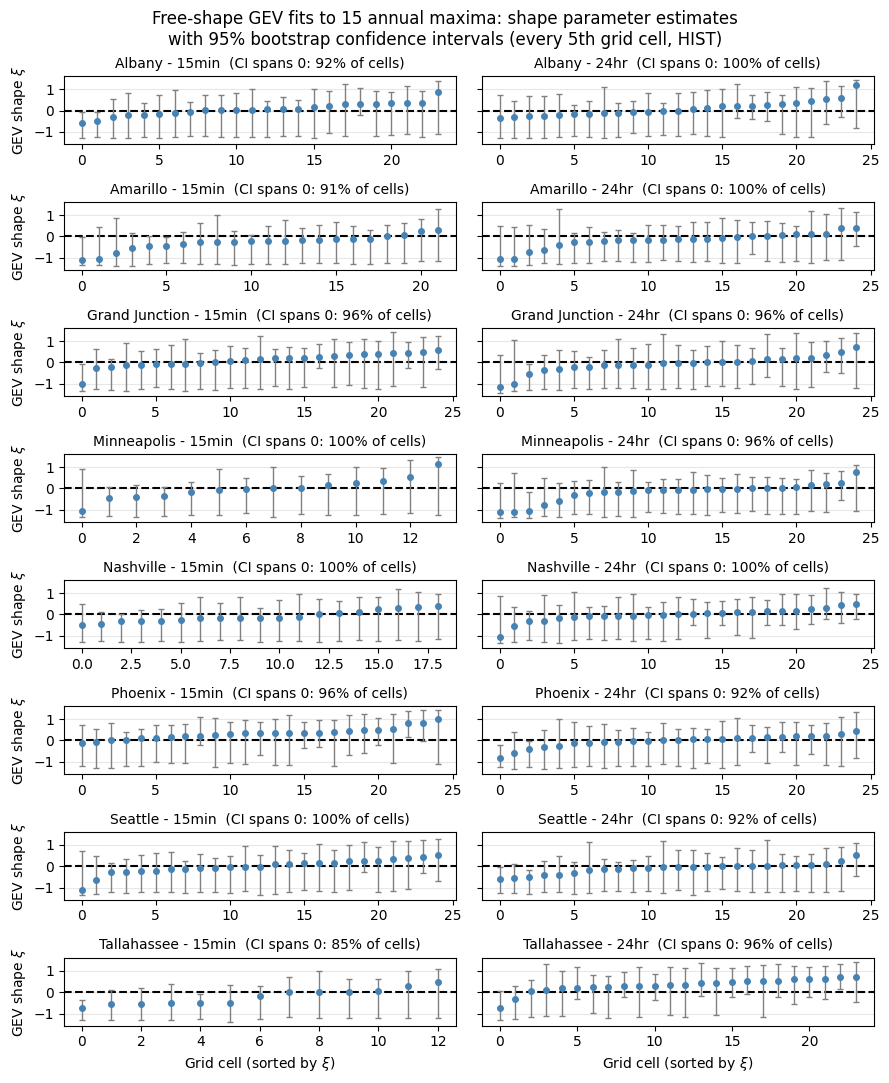

In [19]:
# Supplementary figure: xi estimates with bootstrap CIs, sorted, per city/duration
# Coerce to clean numeric booleans before any aggregation

def format_city_name(city):
    return city.replace('_', ' ').title()

fig, axes = plt.subplots(len(GEV_CHECK_CITIES), len(GEV_CHECK_DURATIONS),
                         figsize=(9, 11), sharey=True, squeeze=False)

for r, city in enumerate(GEV_CHECK_CITIES):
    for cix, dur in enumerate(GEV_CHECK_DURATIONS):
        ax = axes[r][cix]
        g = ok[(ok.city == city) & (ok.duration == dur)].sort_values('xi').reset_index(drop=True)
        xpos = np.arange(len(g))
        ax.errorbar(xpos, g['xi'],
                    yerr=[g['xi'] - g['xi_lo'], g['xi_hi'] - g['xi']],
                    fmt='o', ms=4, color='steelblue', ecolor='gray',
                    elinewidth=1, capsize=2, zorder=10)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=5)
        pct = 100 * g['ci_includes_0'].mean()
        ax.set_title(f"{format_city_name(city)} - {dur}  "
                     f"(CI spans 0: {pct:.0f}% of cells)", fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        if cix == 0:
            ax.set_ylabel(r'GEV shape $\xi$')
        if r == len(GEV_CHECK_CITIES) - 1:
            ax.set_xlabel('Grid cell (sorted by $\\xi$)')

plt.suptitle('Free-shape GEV fits to 15 annual maxima: shape parameter estimates\n'
             'with 95% bootstrap confidence intervals (every 5th grid cell, HIST)',
             fontsize=12)
plt.tight_layout()
fig.savefig(f'gev_shape_check_{VERSION_TAG}.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
g = ok[(ok.city=='seattle') & (ok.duration=='15min')]
print(g[['xi','xi_lo','xi_hi','ci_includes_0','lr_rejects_gumbel']])
print("includes 0:", 100*g['ci_includes_0'].mean(), "%  |  LR rejects:", 100*g['lr_rejects_gumbel'].mean(), "%")

           xi     xi_lo     xi_hi  ci_includes_0  lr_rejects_gumbel
300 -0.026964 -1.157293  0.942268            1.0                0.0
301  0.124752 -1.204160  0.749824            1.0                0.0
302  0.139723 -1.111640  0.645770            1.0                0.0
303  0.253190 -1.121293  1.018283            1.0                0.0
304  0.404108 -1.059055  1.197066            1.0                0.0
305  0.145242 -1.151152  1.058760            1.0                0.0
306 -1.093983 -1.359615  0.715761            1.0                1.0
307 -0.016390 -1.328646  0.524982            1.0                0.0
308  0.330095 -1.157459  1.167750            1.0                0.0
309 -0.249401 -1.251714  0.330402            1.0                0.0
310 -0.120569 -1.220327  0.684721            1.0                0.0
311 -0.634725 -1.293442  0.467280            1.0                0.0
312 -0.036754 -1.262450  0.480036            1.0                0.0
313 -0.202326 -1.213429  0.606490            1.0

In [21]:
gev_df.groupby(['city','duration']).size()
gev_df.groupby(['city','duration'])['degenerate'].sum()

city            duration
albany          15min        1
                24hr         0
amarillo        15min        2
                24hr         0
grand_junction  15min        0
                24hr         0
minneapolis     15min       11
                24hr         0
nashville       15min        6
                24hr         0
phoenix         15min        0
                24hr         0
seattle         15min        0
                24hr         0
tallahassee     15min       10
                24hr         1
Name: degenerate, dtype: int64

In [22]:
domain_check = []
for city in GEV_CHECK_CITIES:
    ds_am = load_combined_maxima(city)
    if ds_am is None:
        continue
    lat_dim = 'south_north' if 'south_north' in ds_am.dims else \
              [d for d in ds_am.dims if d != 'year'][0]
    lon_dim = 'west_east' if 'west_east' in ds_am.dims else \
              [d for d in ds_am.dims if d not in ('year', lat_dim)][0]

    n_lat = ds_am.dims[lat_dim]
    n_lon = ds_am.dims[lon_dim]
    n_i = len(range(0, n_lat, CELL_STRIDE))
    n_j = len(range(0, n_lon, CELL_STRIDE))

    domain_check.append({'city': city, 'n_lat': n_lat, 'n_lon': n_lon,
                          'n_stride_i': n_i, 'n_stride_j': n_j,
                          'n_points_expected': n_i * n_j})
    ds_am.close()

domain_df = pd.DataFrame(domain_check)
print(domain_df.to_string(index=False))

          city  n_lat  n_lon  n_stride_i  n_stride_j  n_points_expected
        albany     21     21           5           5                 25
      amarillo     21     21           5           5                 25
grand_junction     21     21           5           5                 25
   minneapolis     21     21           5           5                 25
     nashville     21     21           5           5                 25
       phoenix     21     21           5           5                 25
       seattle     21     21           5           5                 25
   tallahassee     21     21           5           5                 25


In [23]:
diag = []
for city in GEV_CHECK_CITIES:
    ds_am = load_combined_maxima(city)
    if ds_am is None:
        continue
    lat_dim = 'south_north' if 'south_north' in ds_am.dims else \
              [d for d in ds_am.dims if d != 'year'][0]
    lon_dim = 'west_east' if 'west_east' in ds_am.dims else \
              [d for d in ds_am.dims if d not in ('year', lat_dim)][0]

    for dur in GEV_CHECK_DURATIONS:
        var = f"max_intensity_{dur}"
        if var not in ds_am.data_vars:
            diag.append({'city': city, 'duration': dur, 'status': 'var_missing', 'count': 25})
            continue

        n_none = n_short = n_deg = n_ok = 0
        for i in range(0, ds_am.dims[lat_dim], CELL_STRIDE):
            for j in range(0, ds_am.dims[lon_dim], CELL_STRIDE):
                am = ds_am[var].isel({lat_dim: i, lon_dim: j}).values
                x = am[~np.isnan(am)]
                fit = fit_gev_free_shape(am)
                if fit is None:
                    n_none += 1
                    if len(x) < 10:
                        n_short += 1
                elif fit['degenerate']:
                    n_deg += 1
                else:
                    n_ok += 1

        diag.append({'city': city, 'duration': dur,
                      'n_none_fit': n_none, 'n_short_series': n_short,
                      'n_degenerate': n_deg, 'n_ok': n_ok})
    ds_am.close()

diag_df = pd.DataFrame(diag)
print(diag_df.to_string(index=False))

          city duration  n_none_fit  n_short_series  n_degenerate  n_ok
        albany    15min           0               0             1    24
        albany     24hr           0               0             0    25
      amarillo    15min           0               0             2    23
      amarillo     24hr           0               0             0    25
grand_junction    15min           0               0             0    25
grand_junction     24hr           0               0             0    25
   minneapolis    15min           0               0            11    14
   minneapolis     24hr           0               0             0    25
     nashville    15min           0               0             6    19
     nashville     24hr           0               0             0    25
       phoenix    15min           0               0             0    25
       phoenix     24hr           0               0             0    25
       seattle    15min           0               0             